## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_B/default_models/"
path_to_predictions = pre_path + "predictions/model_B/default_models/"
tag = "Base"
output_parameters = ['T_eff', 'log_g', 'radius']

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading PARSEC dataframe from csv file...


,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.00000,3.4744,2.965,0.0,-0.25,0.090,1.636
1,5.00000,3.4752,2.963,0.0,-0.25,0.092,1.656
2,5.00000,3.4780,2.956,0.0,-0.25,0.098,1.725
3,5.00000,3.4789,2.954,0.0,-0.25,0.100,1.747
4,5.00000,3.4819,2.950,0.0,-0.25,0.106,1.811
...,...,...,...,...,...,...,...
681298,10.25002,3.4812,0.032,7.0,0.50,0.801,143.400
681299,10.25002,3.4776,-0.004,7.0,0.50,0.801,149.900
681300,10.25002,3.4742,-0.038,7.0,0.50,0.800,156.500
681301,10.25002,3.4701,-0.077,7.0,0.50,0.800,164.400


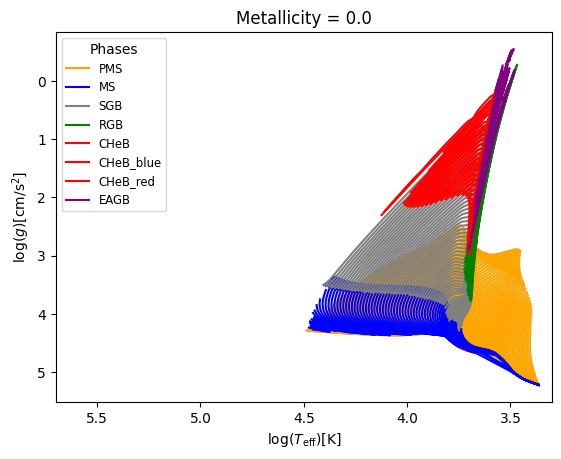

In [4]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.60000,4.4269,4.356,1.0,-0.25,9.714,3.428
1,5.65000,4.4266,4.355,1.0,-0.25,9.714,3.434
2,5.70000,4.4263,4.353,1.0,-0.25,9.714,3.440
3,5.75000,4.4061,4.358,1.0,-0.25,8.856,3.268
4,5.75000,4.4260,4.352,1.0,-0.25,9.714,3.447
...,...,...,...,...,...,...,...
499615,10.25002,3.4812,0.032,7.0,0.50,0.801,143.400
499616,10.25002,3.4776,-0.004,7.0,0.50,0.801,149.900
499617,10.25002,3.4742,-0.038,7.0,0.50,0.800,156.500
499618,10.25002,3.4701,-0.077,7.0,0.50,0.800,164.400


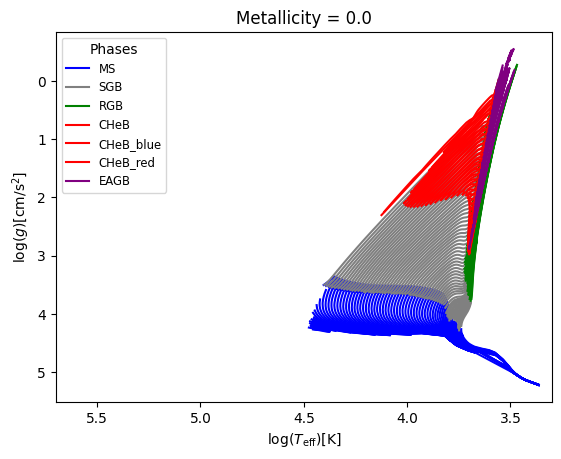

In [5]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6, 7, 8]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [6]:
print_all_uniques(phase_filtered_iso_df)

logAge  : Range : 5.3 - 10.25, Mean : 9.1668, Median : 9.4

logTe  : Range : 3.36 - 4.5177, Mean : 3.7418, Median : 3.7133

logg  : Range : -0.66 - 5.345, Mean : 2.4609, Median : 2.429

Values in label column : 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -2.75, 0.0, 0.25, 0.5 

Mass  : Range : 0.09 - 13.952, Mean : 2.3888, Median : 1.345

Rpol  : Range : 0.11 - 939.1, Mean : 36.9259, Median : 11.08



In [8]:
X_train, X_ivs, y_train, y_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'metallicity', 'Mass'], 
                               y_cols=['logTe', 'logg', 'Rpol'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the logTe parameter : 3.3621 - 4.5177
Median value in train data for the logTe parameter: 3.7134
Mean value in train data for the logTe parameter: 3.7419557180790735

Range in train data for the logg parameter : -0.664 - 5.345
Median value in train data for the logg parameter: 2.429
Mean value in train data for the logg parameter: 2.460199402212348

Range in train data for the Rpol parameter : 0.1056 - 939.1
Median value in train data for the Rpol parameter: 11.08
Mean value in train data for the Rpol parameter: 37.02370043366292

Testing set statistics:
Range in test data for the logTe parameter : 3.3621 - 4.5177
Median value in test data for the logTe parameter: 3.7133
Mean value in test data for the logTe parameter: 3.7413671222128815

Range in test data for the logg parameter : -0.597 - 5.345
Median value in test data for the logg parameter: 2.429
Mean value in test data for the logg parameter: 2.463028901965494

Range in test data f

## Model training

### Linear regression

In [11]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 
T_eff results:
RVE :  0.24812210597513573
RMSE :  0.1367275691834398
MAE :  0.09132873897701474
MedAE :  0.05087956347737732
CORR :  0.498118566807986
MAX_ER :  0.6105525376700216
Percentiles : 
  75th percentile :  0.12105725349995078
  90th percentile :  0.2463323072716249
  95th percentile :  0.29861914973644366
  99th percentile :  0.4746324097336663



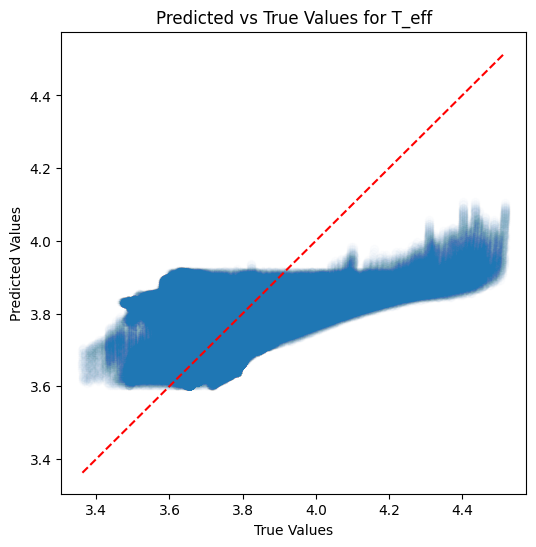

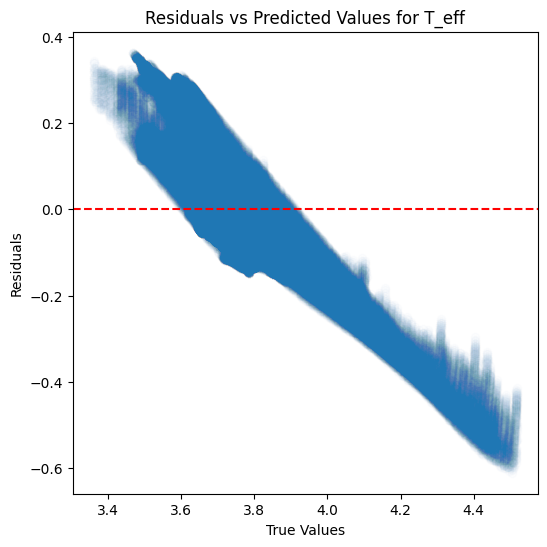

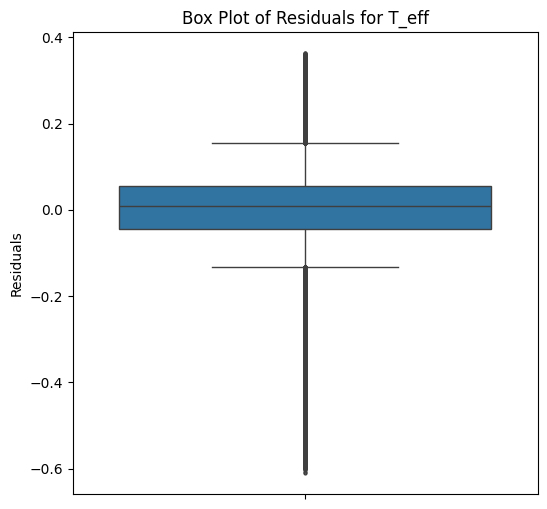

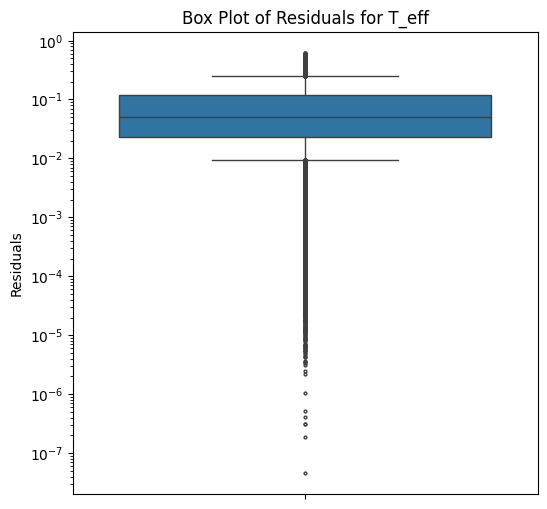

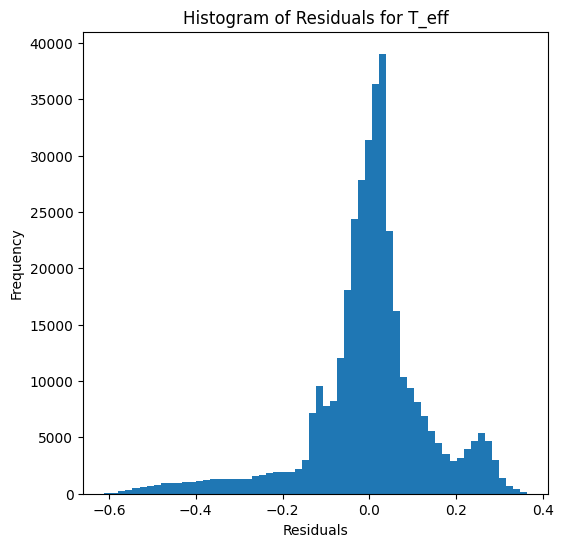

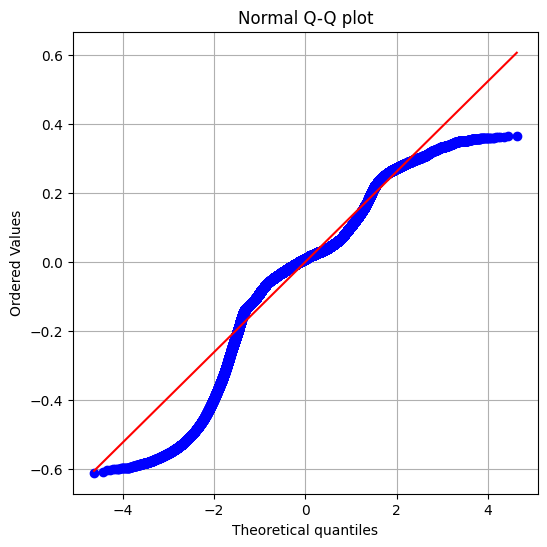


log_g results:
RVE :  0.13322474744723045
RMSE :  0.9729144226577829
MAE :  0.6503127228835889
MedAE :  0.2608936728201674
CORR :  0.36499965576850685
MAX_ER :  3.6702146832020324
Percentiles : 
  75th percentile :  1.123314544097115
  90th percentile :  1.8498102842870832
  95th percentile :  2.1235408469368684
  99th percentile :  2.649124098303397



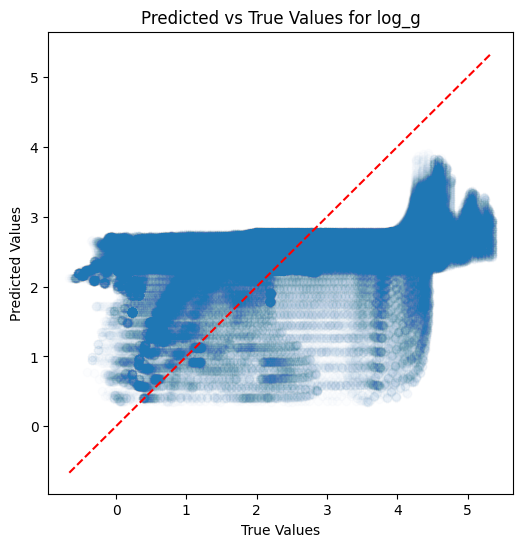

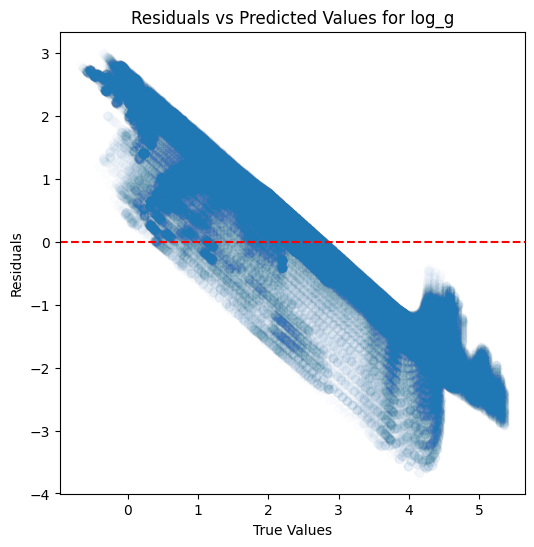

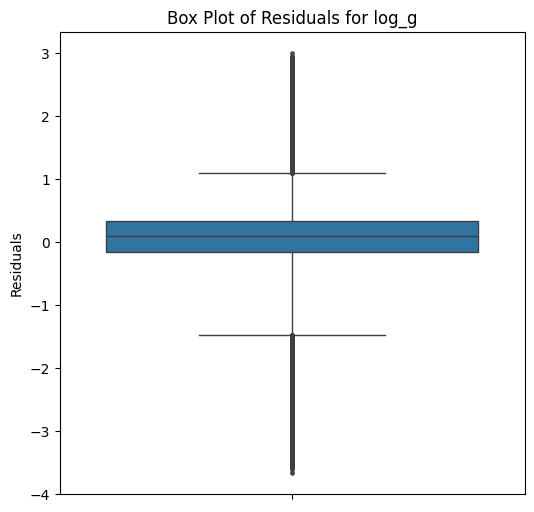

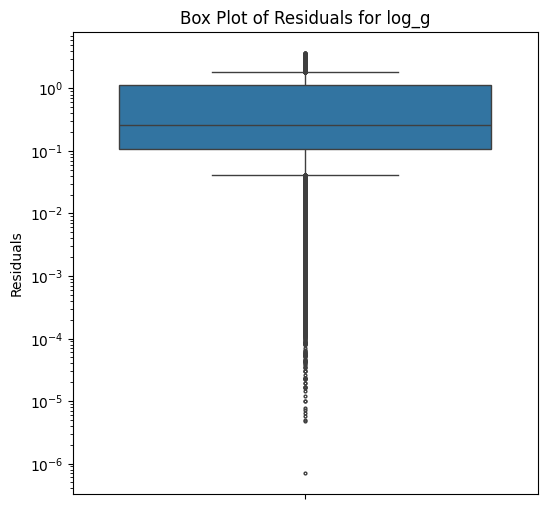

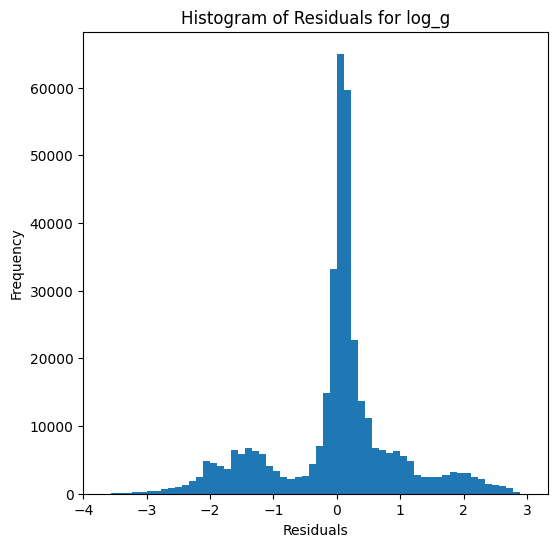

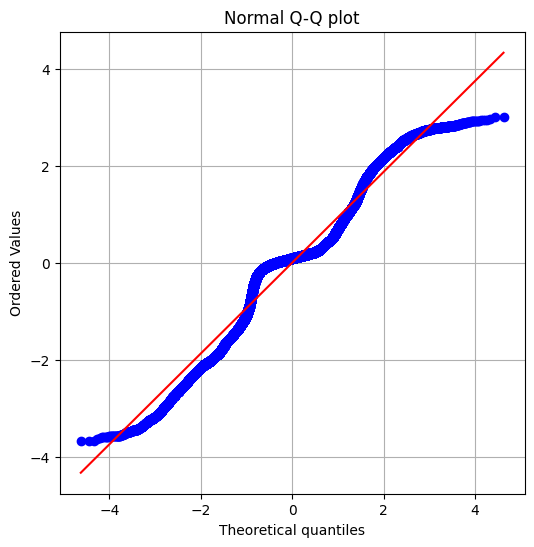


radius results:
RVE :  0.320563068105964
RMSE :  67.53468122826189
MAE :  30.218293857308396
MedAE :  9.983773643576624
CORR :  0.5661828932183565
MAX_ER :  817.0581667446755
Percentiles : 
  75th percentile :  22.69558173858609
  90th percentile :  79.78206984116116
  95th percentile :  144.66315244450936
  99th percentile :  297.8583745804247



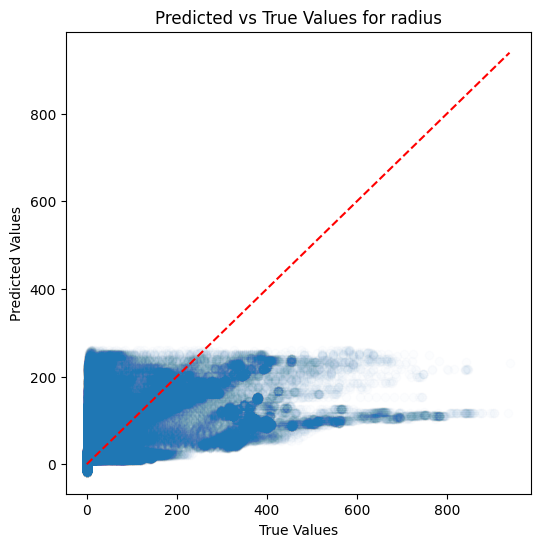

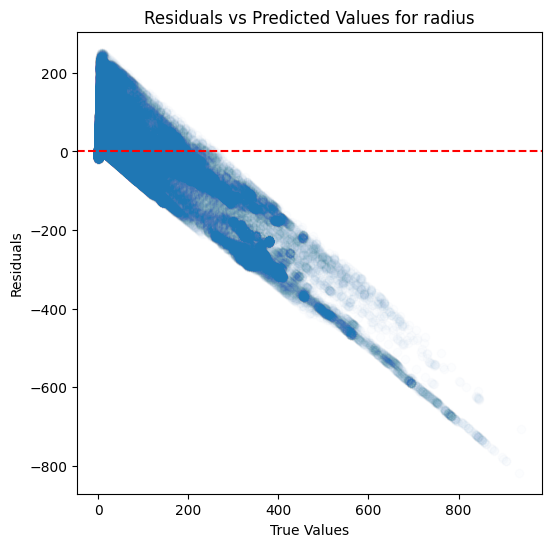

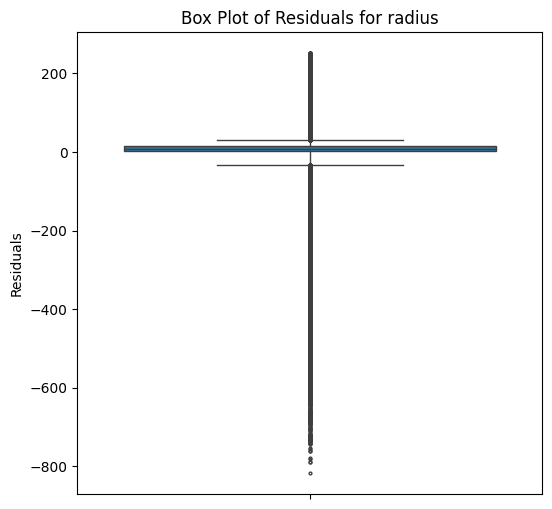

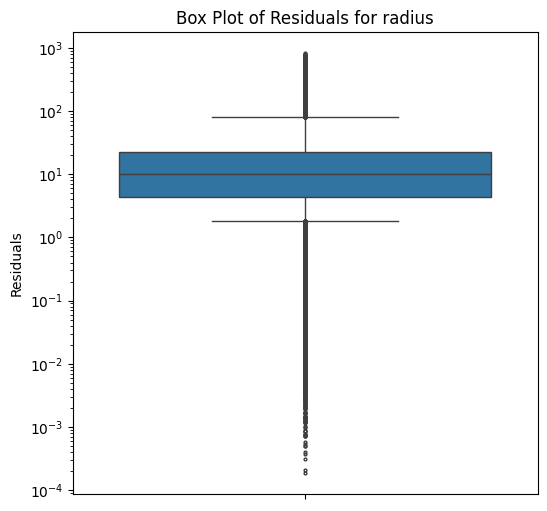

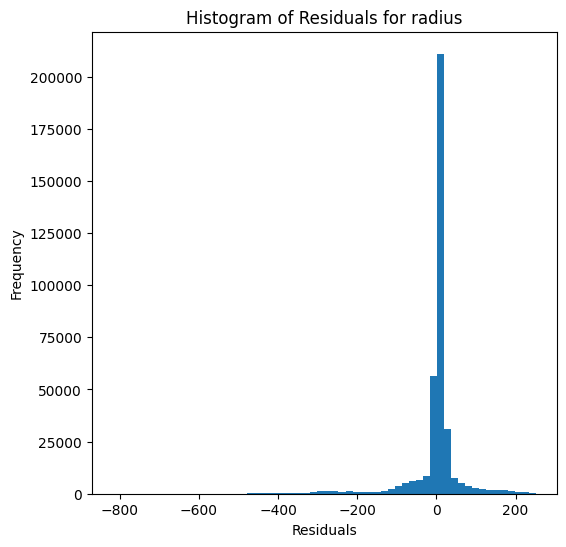

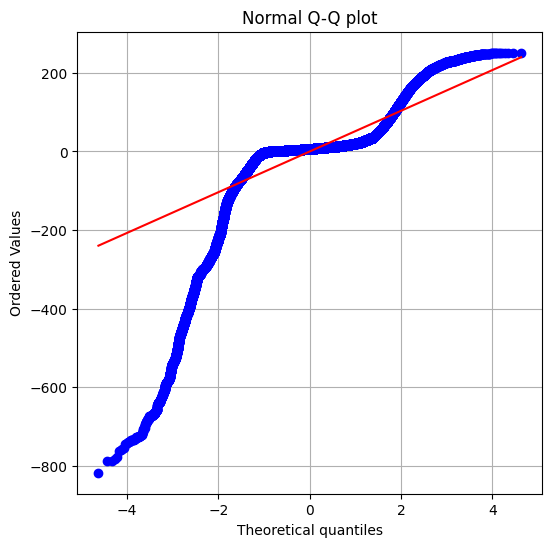

In [12]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False) #, override=False, use_preds=True)

### Decision tree

In [13]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



T_eff results:
RVE :  0.9245412507429231
RMSE :  0.04331560632642625
MAE :  0.01525475967442564
MedAE :  0.003030303030303383
CORR :  0.9618493432802782
MAX_ER :  0.8372666666666673
Percentiles : 
  75th percentile :  0.012503076923076062
  90th percentile :  0.03384247578649645
  95th percentile :  0.07908164245810115
  99th percentile :  0.1828000000000003



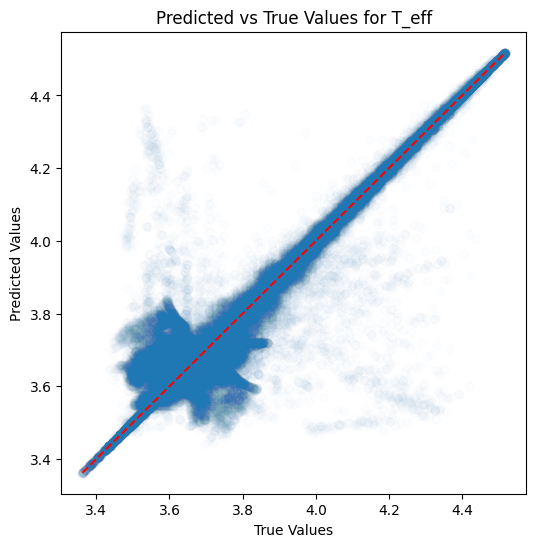

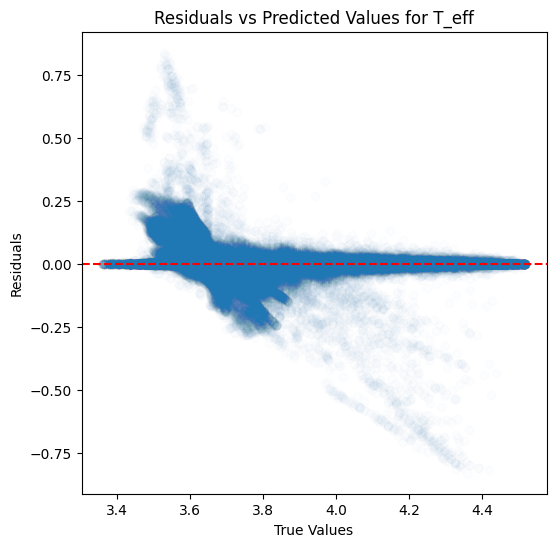

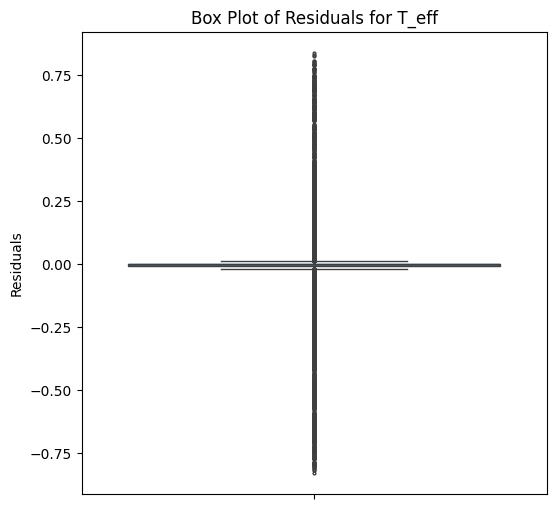

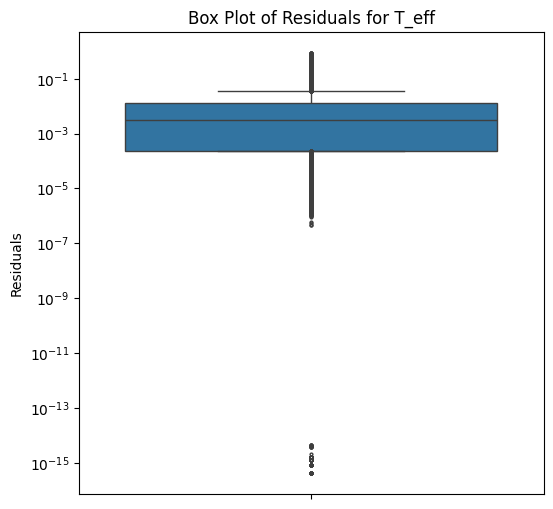

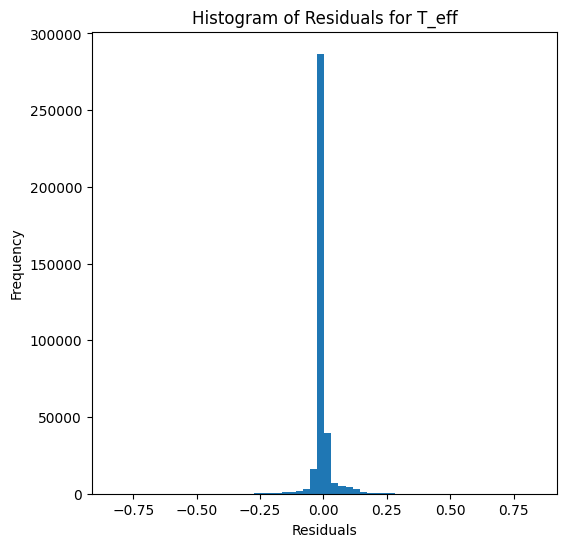

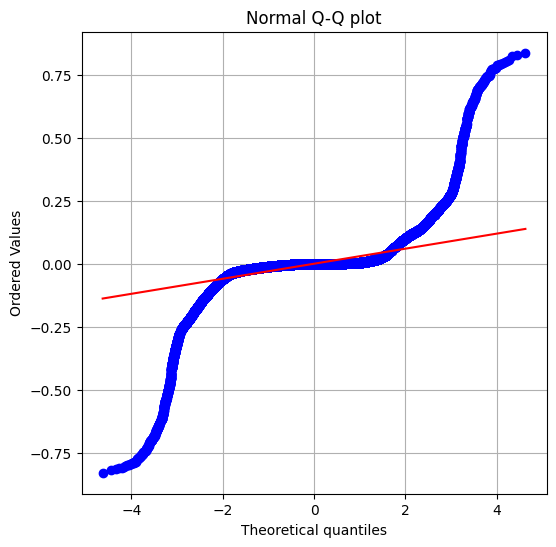

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



log_g results:
RVE :  0.7594009575639977
RMSE :  0.5125940405302718
MAE :  0.19234463148311845
MedAE :  0.03428571428571425
CORR :  0.8748814697125494
MAX_ER :  4.853000000000001
Percentiles : 
  75th percentile :  0.13825000000000043
  90th percentile :  0.4283474548440065
  95th percentile :  1.1396160377358446
  99th percentile :  2.5175



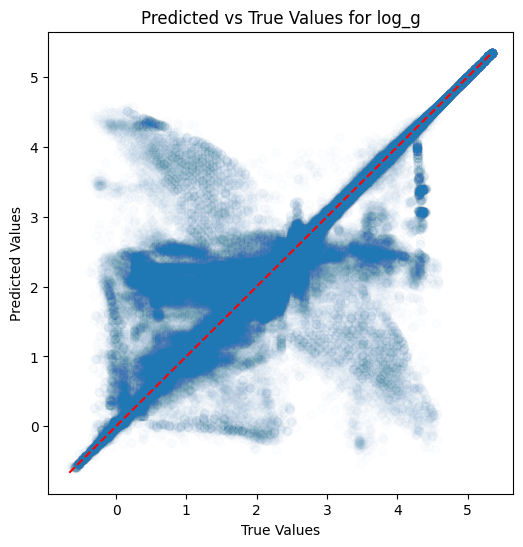

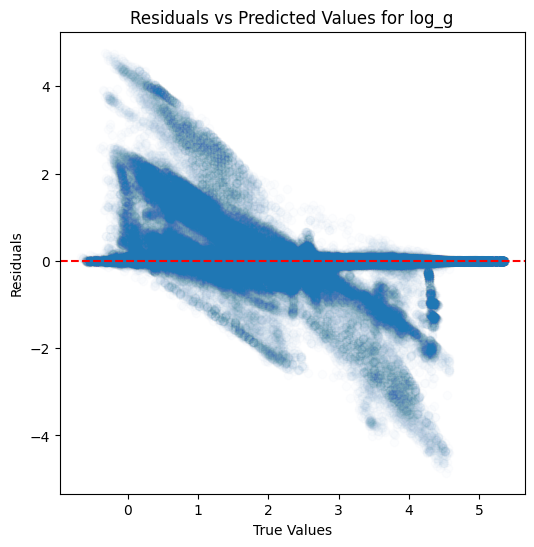

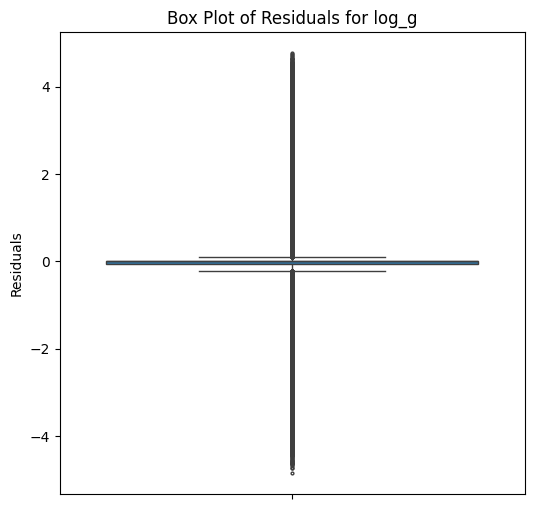

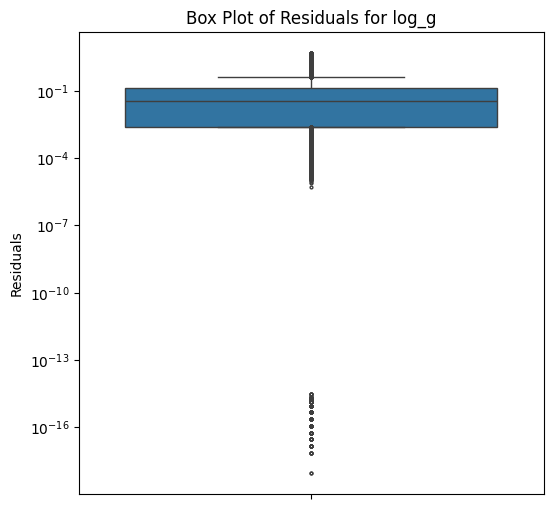

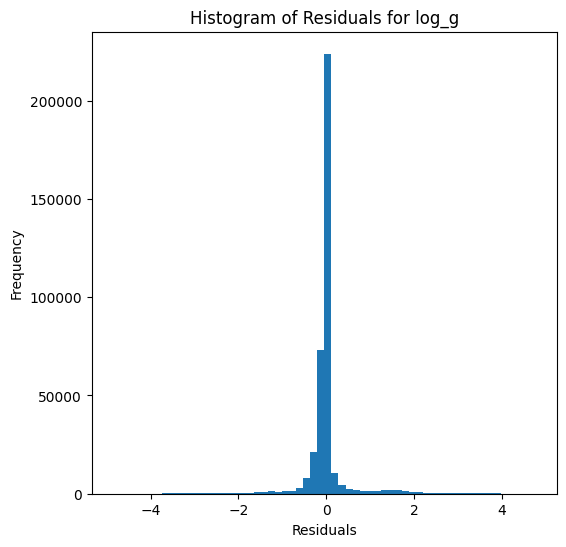

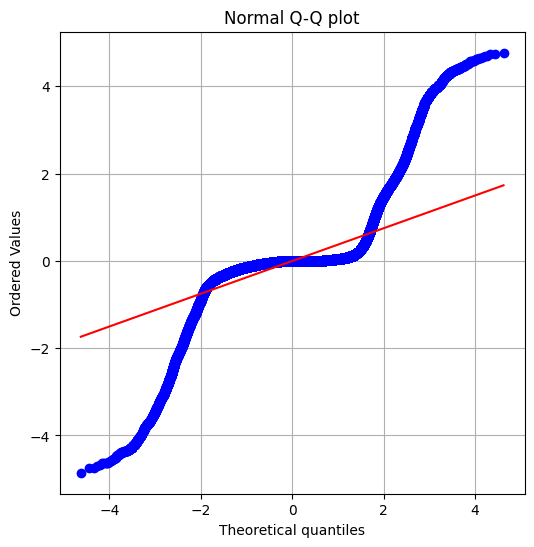


radius results:
RVE :  0.8328636789610174
RMSE :  33.49577175778482
MAE :  9.513473490953443
MedAE :  0.8660000000000014
CORR :  0.9146697828907815
MAX_ER :  831.565
Percentiles : 
  75th percentile :  5.489572704081633
  90th percentile :  18.909999999999997
  95th percentile :  45.98273517786561
  99th percentile :  153.65439999999947



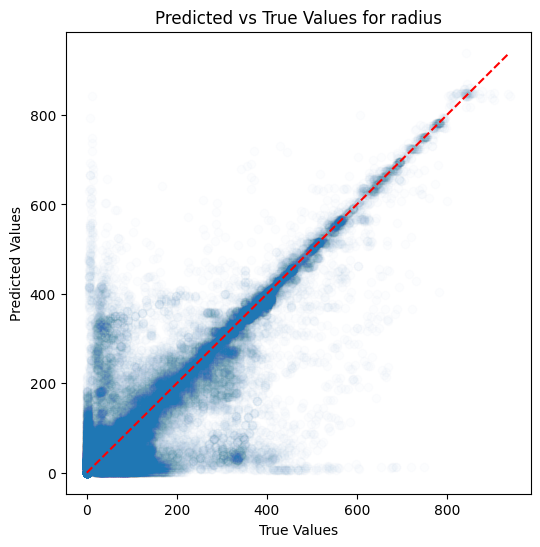

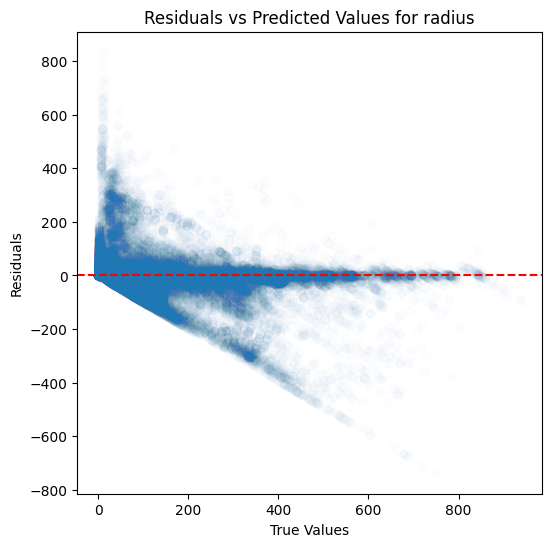

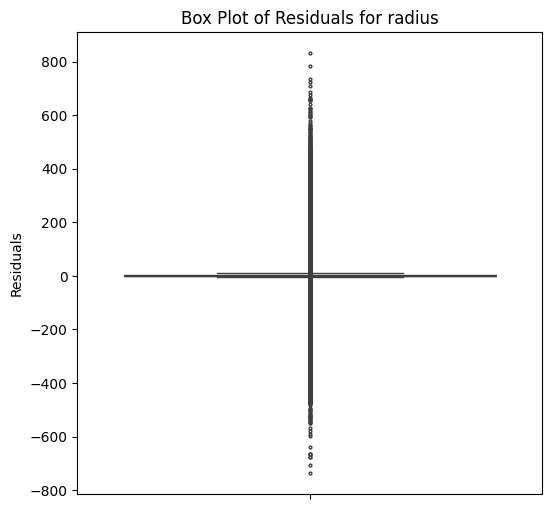

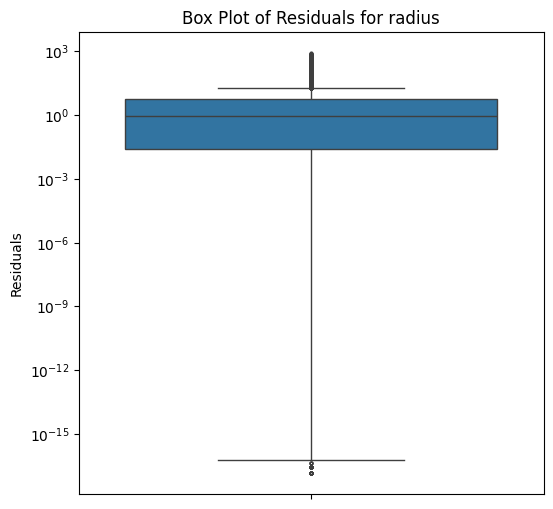

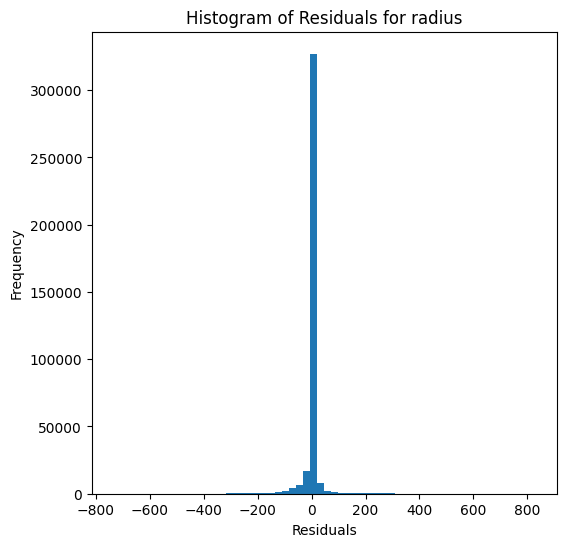

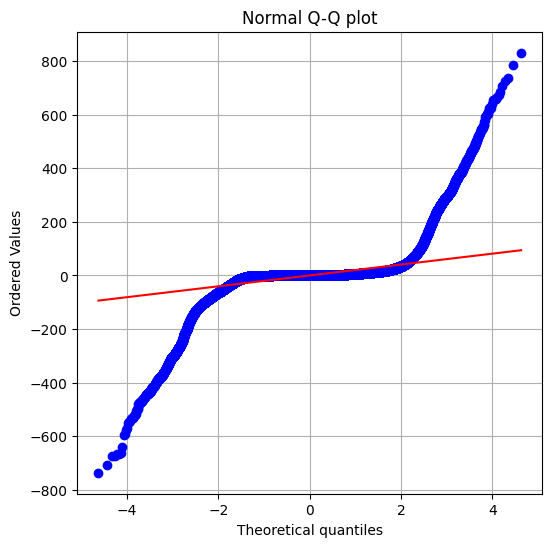

In [14]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, path_to_predictions, tag, random_state=13, override=True, use_preds=False) #, override=False, use_preds=True)

### K-nearest neighbours

In [15]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 
T_eff results:
RVE :  0.9115968633212425
RMSE :  0.046929319199185554
MAE :  0.017819468075737564
MedAE :  0.0030200000000002447
CORR :  0.9547779857750608
MAX_ER :  0.8681000000000001
Percentiles : 
  75th percentile :  0.019159999999999844
  90th percentile :  0.045259999999999856
  95th percentile :  0.08106000000000035
  99th percentile :  0.17595159999999951



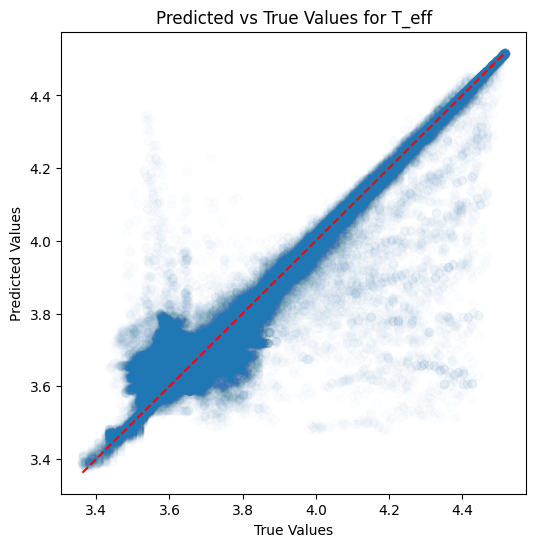

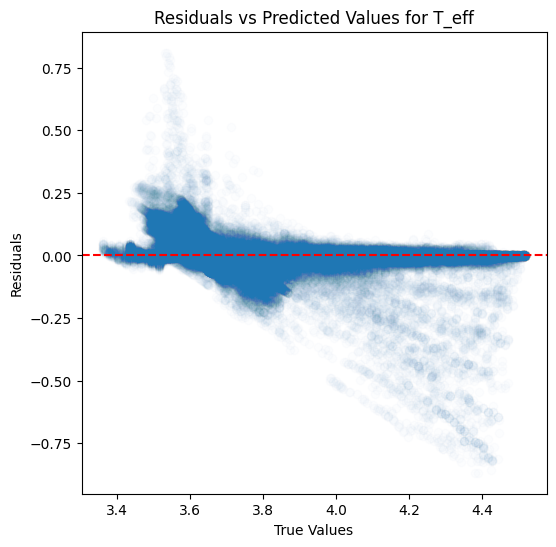

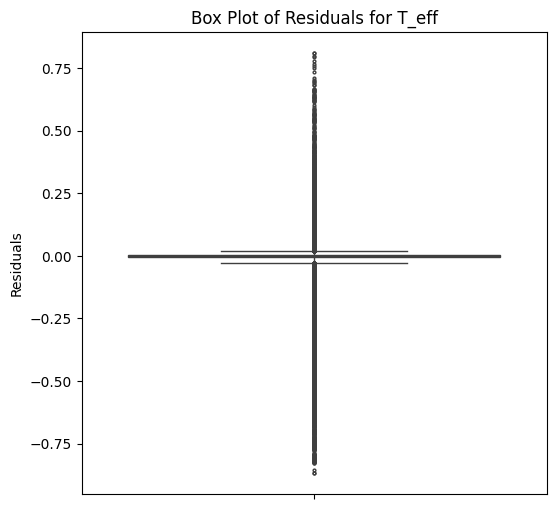

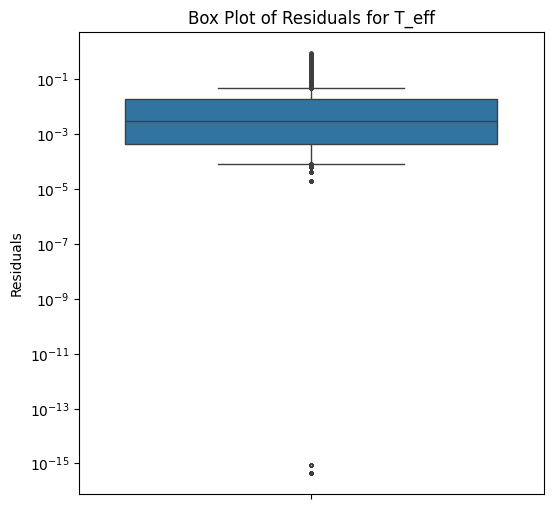

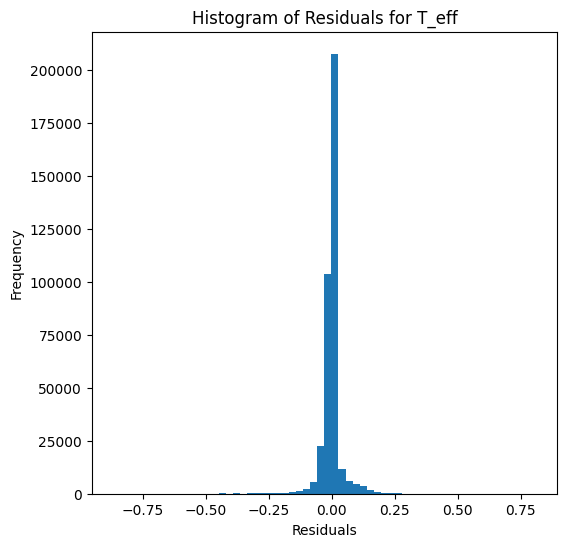

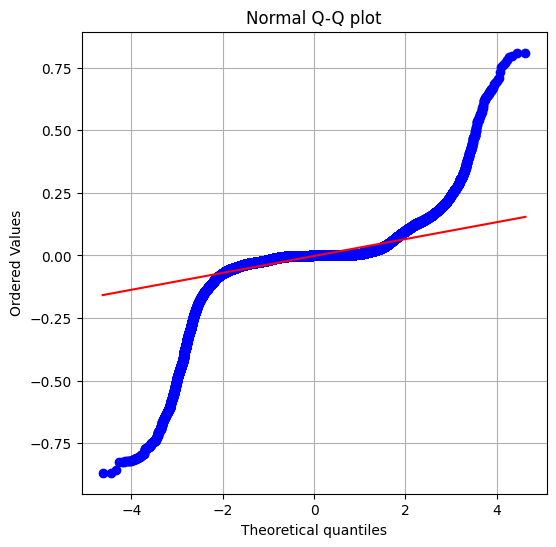


log_g results:
RVE :  0.7822590310985804
RMSE :  0.487740727705795
MAE :  0.20835222182191798
MedAE :  0.0264000000000002
CORR :  0.8854387702544766
MAX_ER :  4.6411999999999995
Percentiles : 
  75th percentile :  0.19459999999999944
  90th percentile :  0.6143999999999997
  95th percentile :  1.121
  99th percentile :  2.142



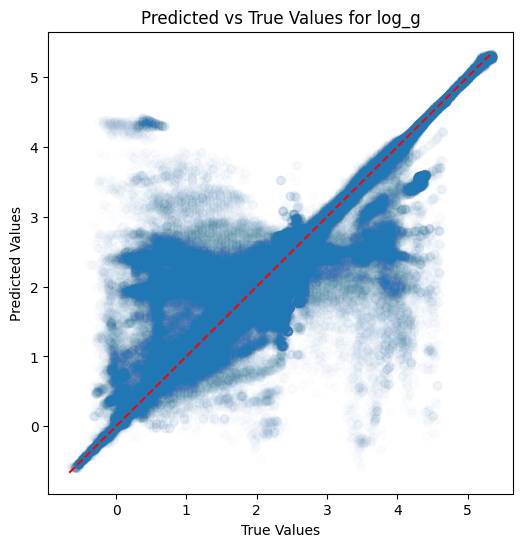

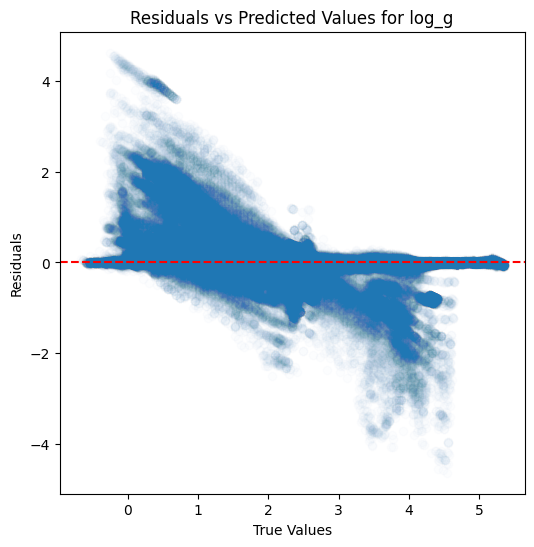

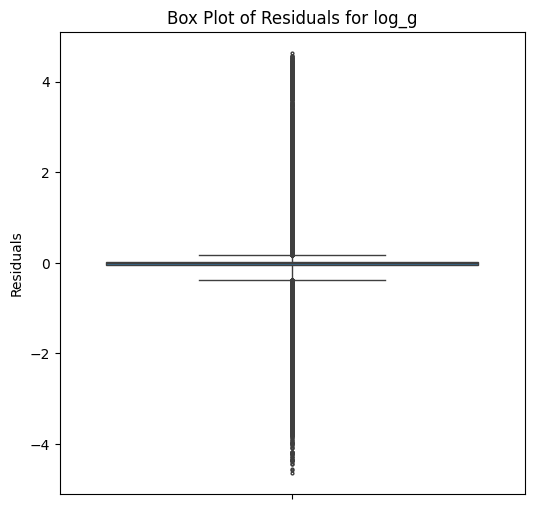

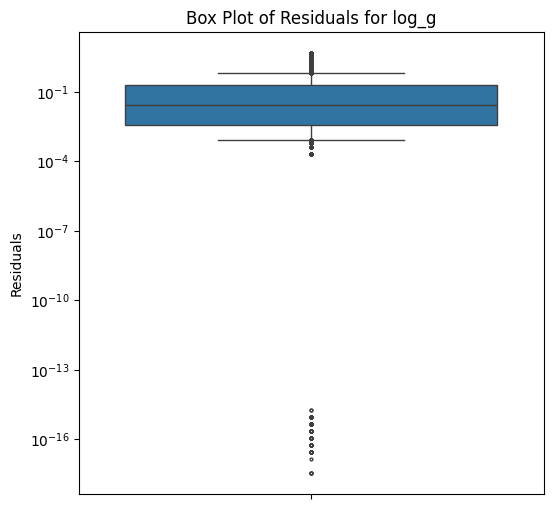

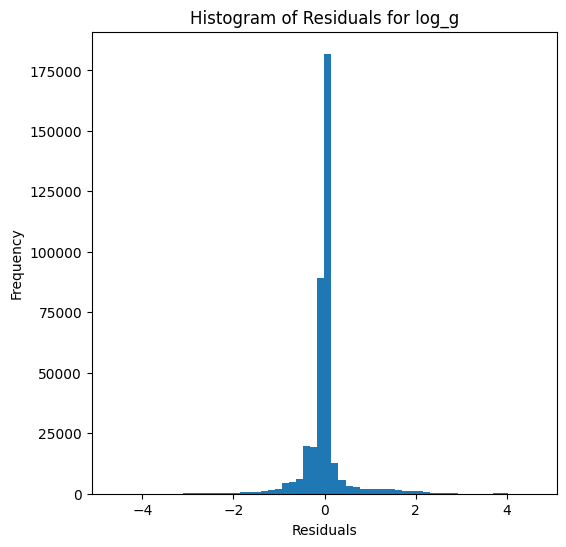

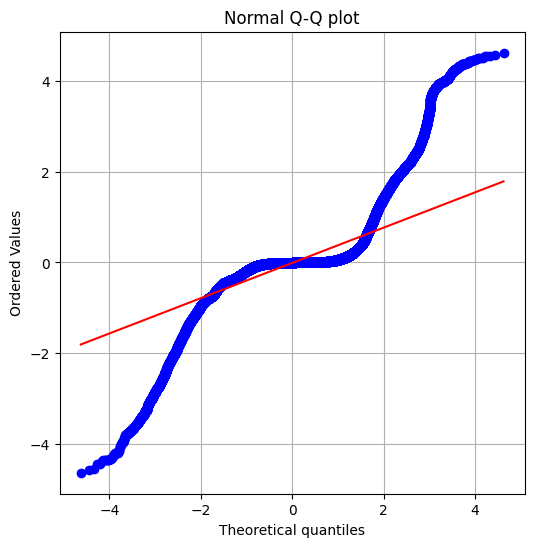


radius results:
RVE :  0.8525925235607505
RMSE :  31.461870571191284
MAE :  10.104332681211053
MedAE :  0.38760000000000083
CORR :  0.9244075292546817
MAX_ER :  848.88
Percentiles : 
  75th percentile :  6.526
  90th percentile :  26.559999999999963
  95th percentile :  51.36273999999998
  99th percentile :  139.53247999999908



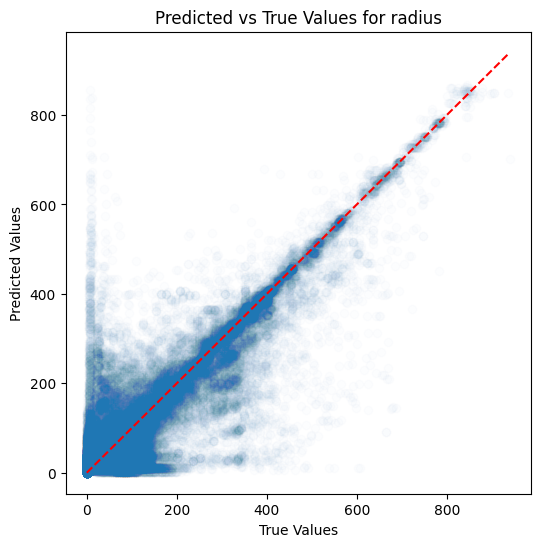

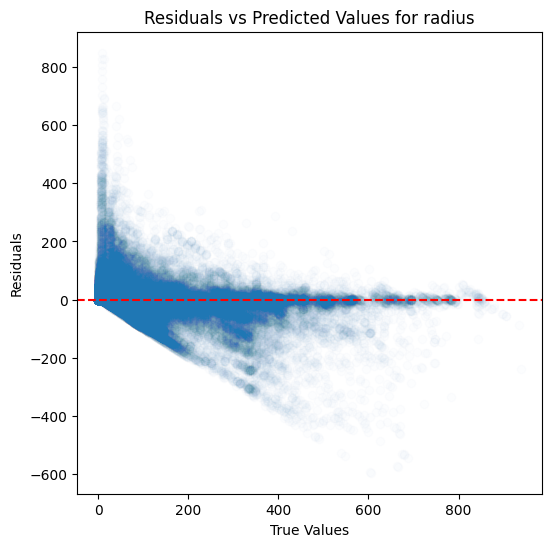

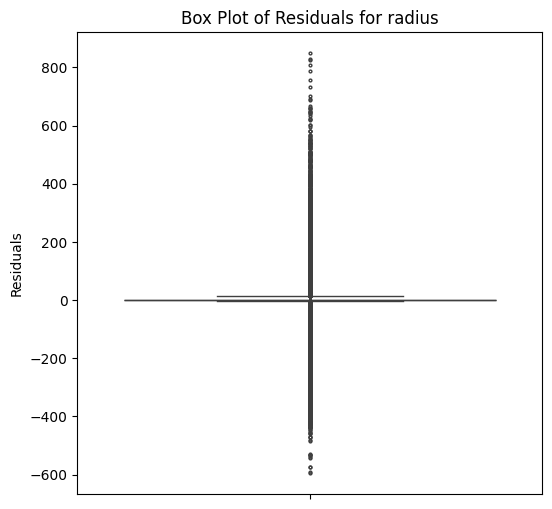

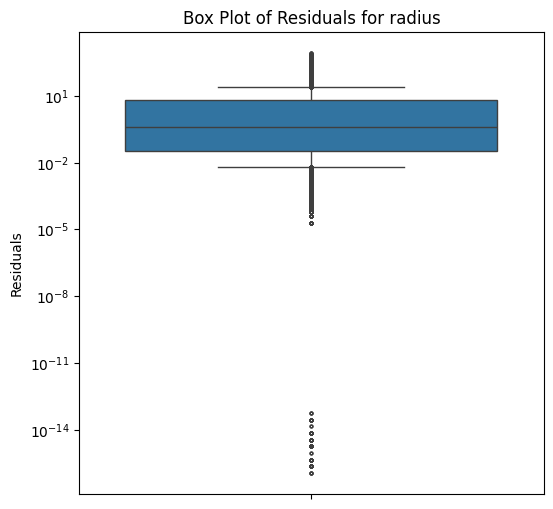

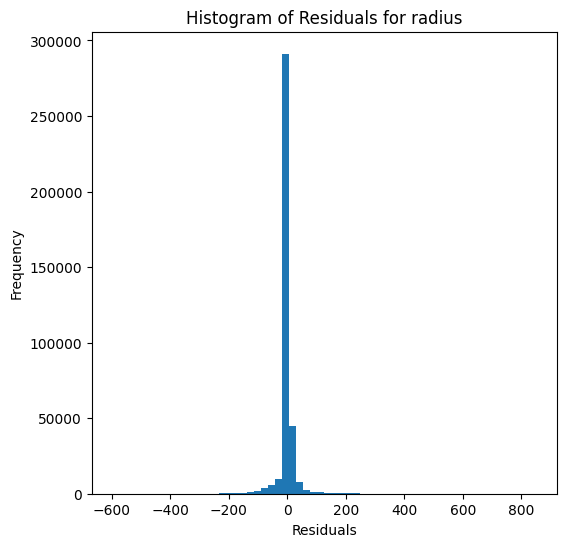

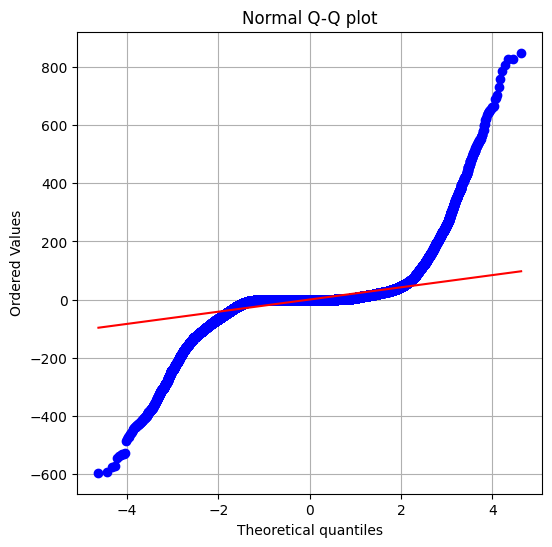

In [16]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False) #, override=False, use_preds=True)

### Random forests

In [17]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 
T_eff results:
RVE :  0.9378213838315144
RMSE :  0.039321064540473696
MAE :  0.015033904773414332
MedAE :  0.0033886503029645354
CORR :  0.9684559684563084
MAX_ER :  0.8246224357142848
Percentiles : 
  75th percentile :  0.01321563486006161
  90th percentile :  0.035962777365220876
  95th percentile :  0.07638960333333199
  99th percentile :  0.1600248918343895



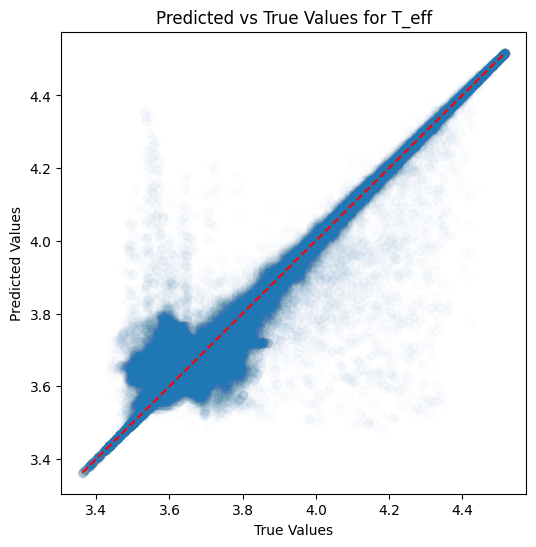

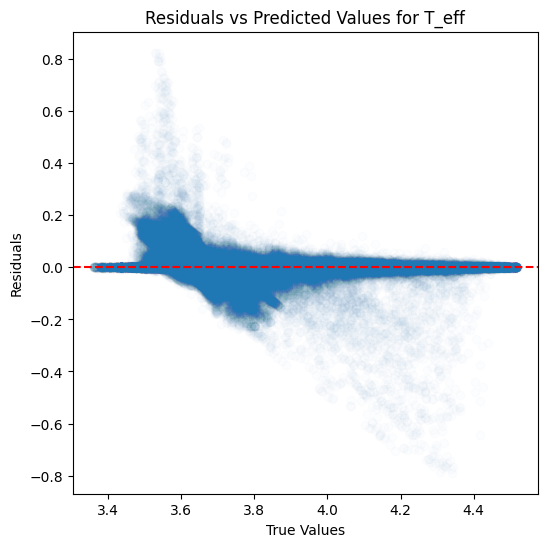

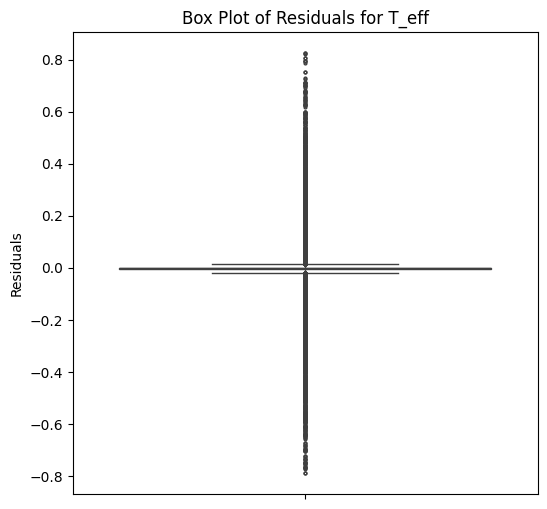

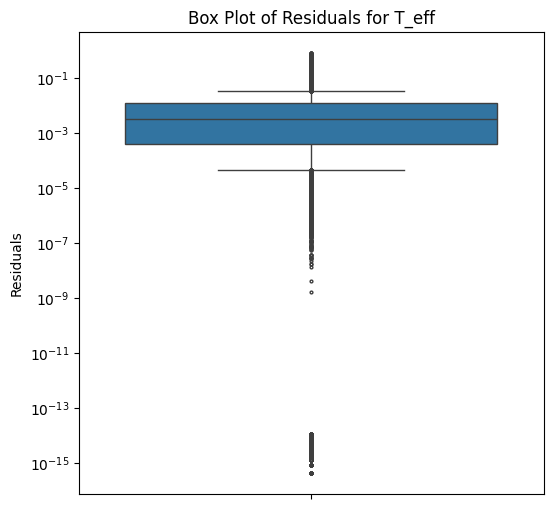

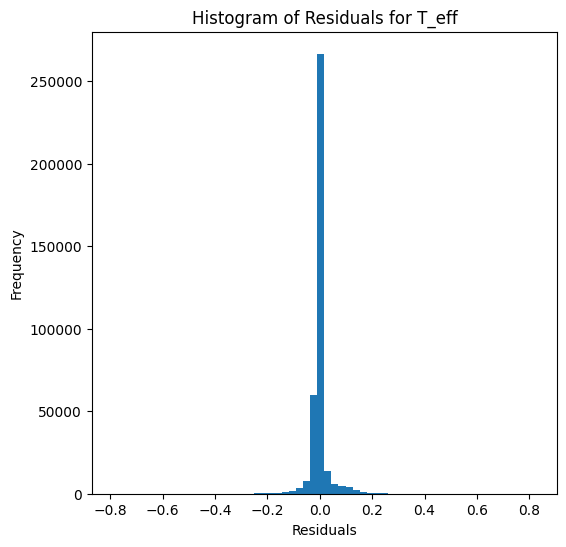

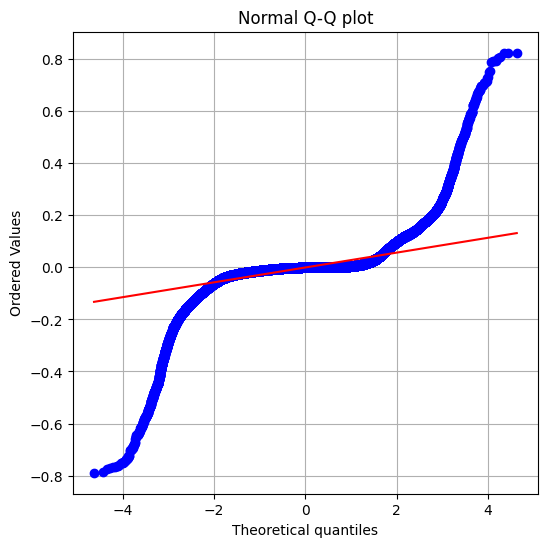


log_g results:
RVE :  0.8000153936846237
RMSE :  0.4673428075323898
MAE :  0.18969574414803522
MedAE :  0.03816003191619899
CORR :  0.895164962922445
MAX_ER :  4.630103333333327
Percentiles : 
  75th percentile :  0.15213921051130208
  90th percentile :  0.4623970362733964
  95th percentile :  1.0924625666666659
  99th percentile :  2.168353606061266



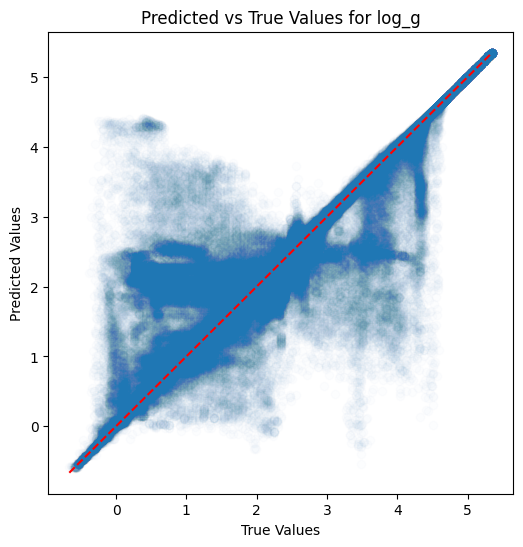

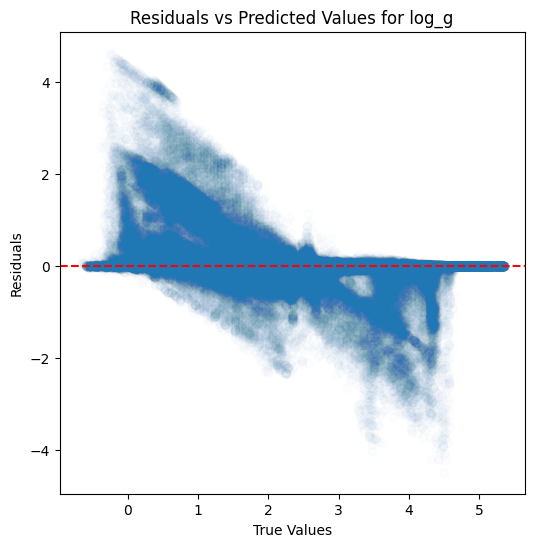

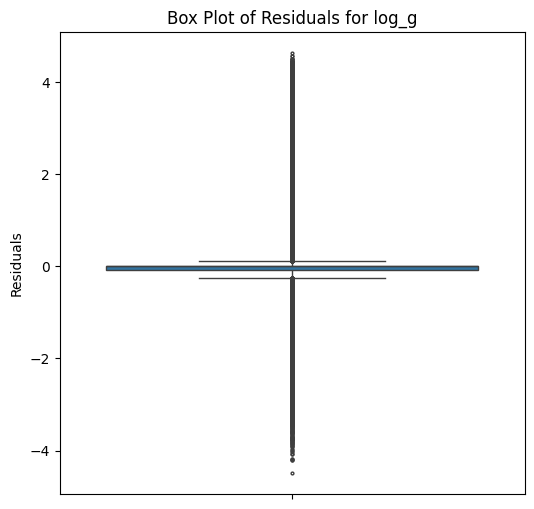

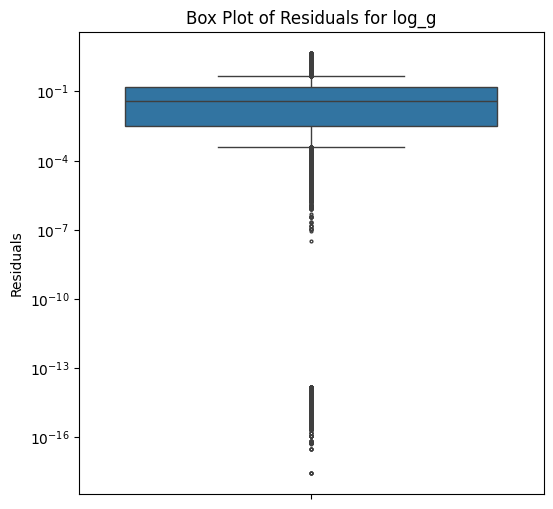

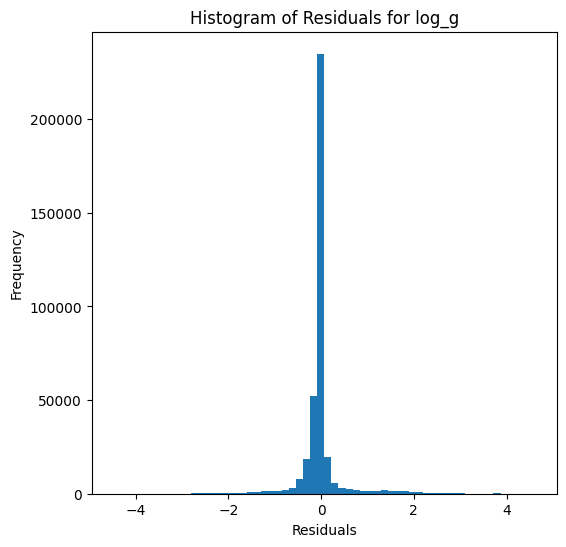

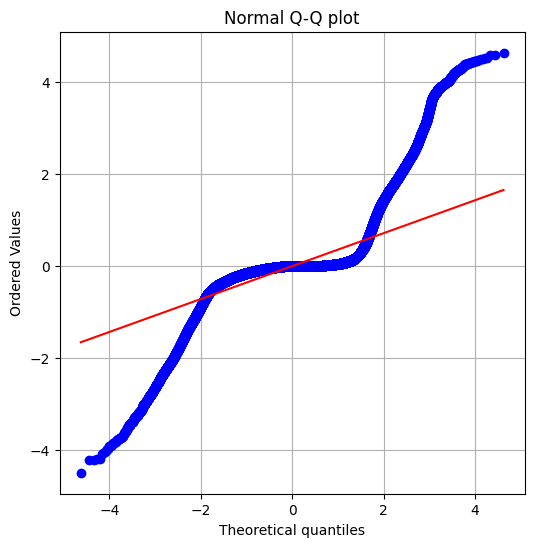


radius results:
RVE :  0.862642078240262
RMSE :  30.3659668294072
MAE :  9.336641335988988
MedAE :  1.0485489523809495
CORR :  0.9293767733730398
MAX_ER :  791.5525
Percentiles : 
  75th percentile :  6.058162505794075
  90th percentile :  20.26006076692605
  95th percentile :  45.77997378571422
  99th percentile :  142.95341170793472



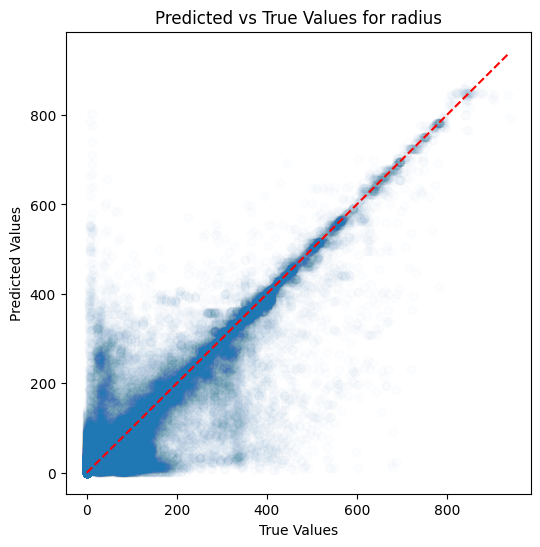

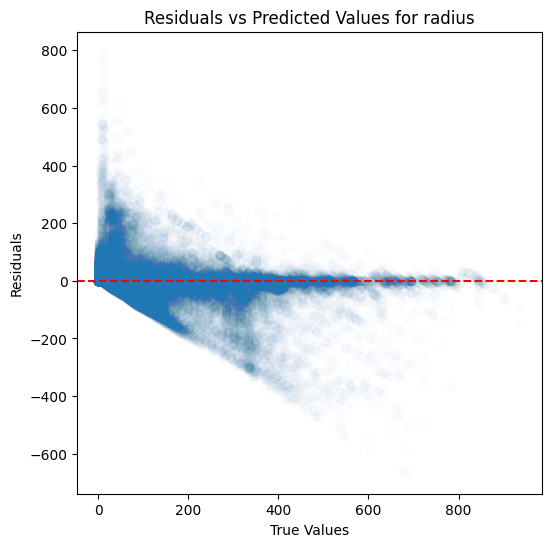

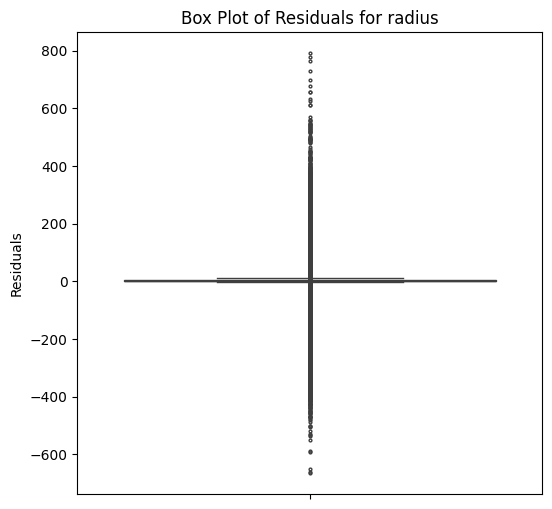

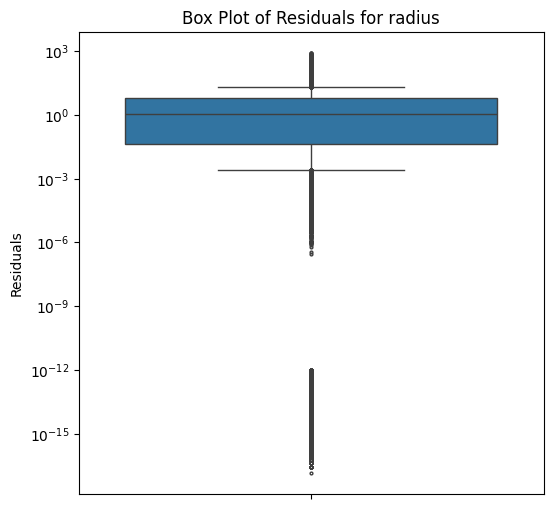

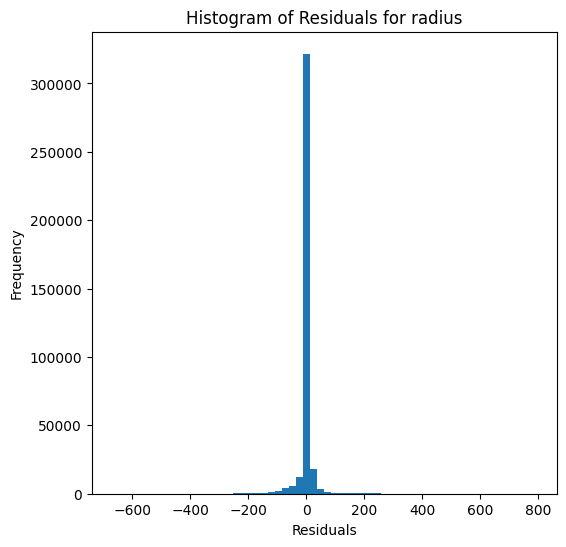

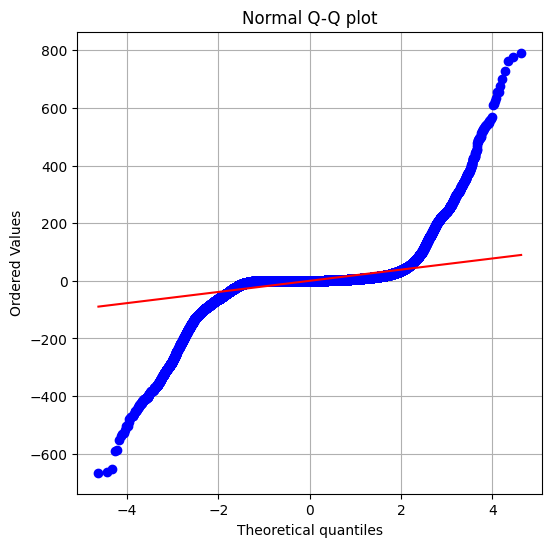

In [18]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False, n_jobs=5) #, override=False, use_preds=True)

### XGBoost

In [19]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 2 3 4 5 6 7 8 9 10 
T_eff results:
RVE :  0.7348764279066914
RMSE :  0.08119076015867398
MAE :  0.041475672954746995
MedAE :  0.011575374603271626
CORR :  0.8574582640085961
MAX_ER :  0.7421421470642091
Percentiles : 
  75th percentile :  0.04758184223175044
  90th percentile :  0.12239622978210453
  95th percentile :  0.18082530364990212
  99th percentile :  0.32996153056335437



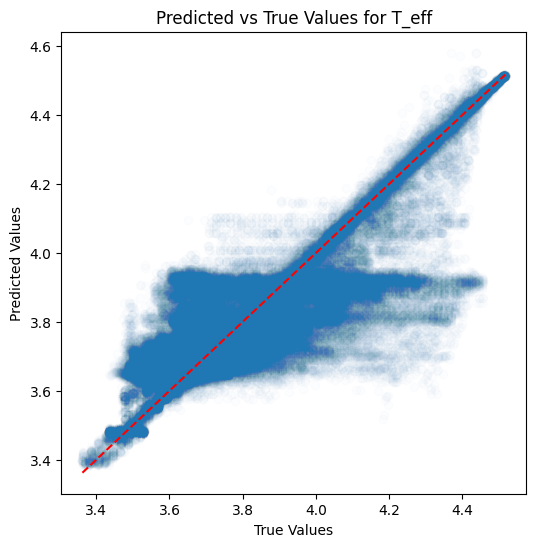

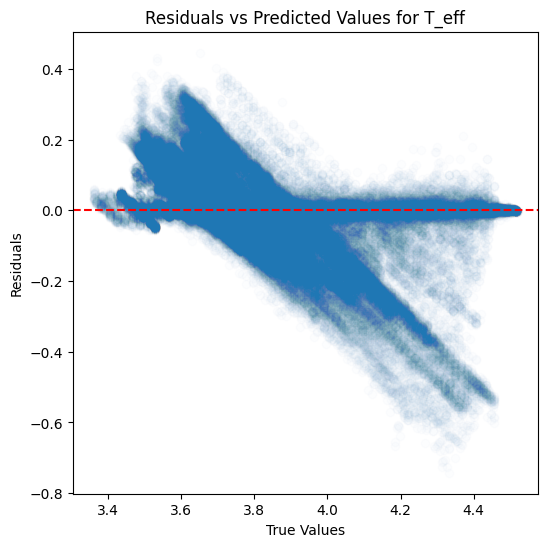

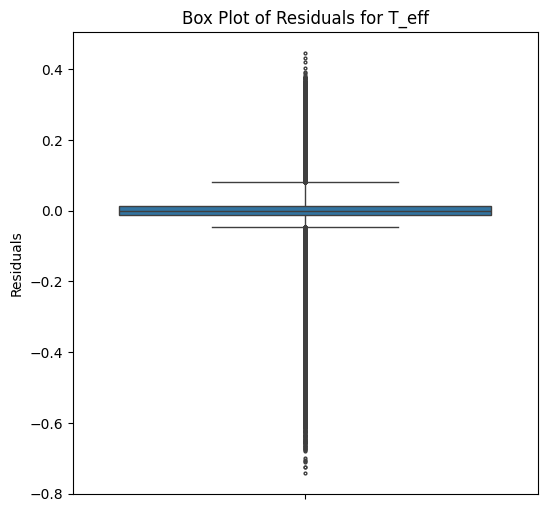

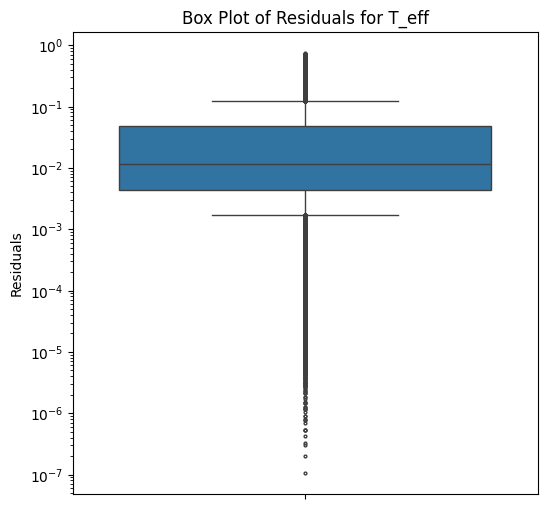

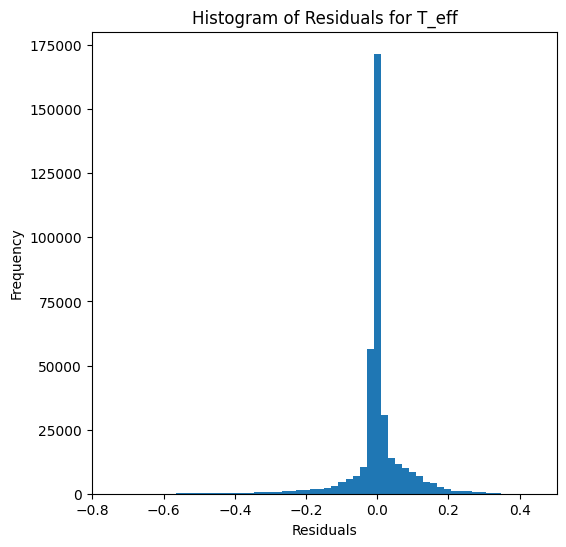

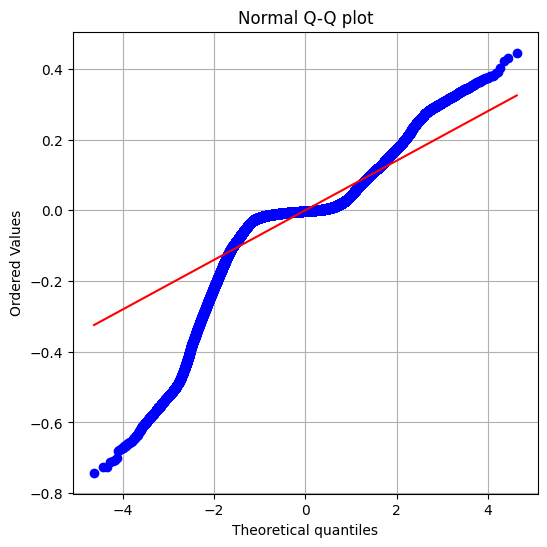


log_g results:
RVE :  0.6848606387237541
RMSE :  0.5866414104160291
MAE :  0.34219164841039273
MedAE :  0.1314182605743408
CORR :  0.8283184244678113
MAX_ER :  4.314375171661377
Percentiles : 
  75th percentile :  0.4190119905471802
  90th percentile :  1.0582434791564945
  95th percentile :  1.4313525251388546
  99th percentile :  2.045004913787842



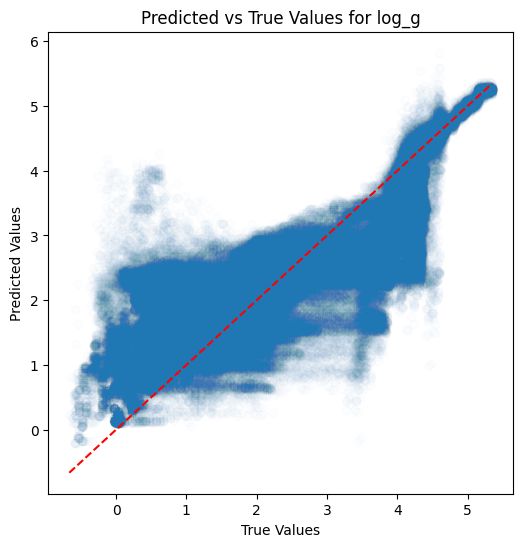

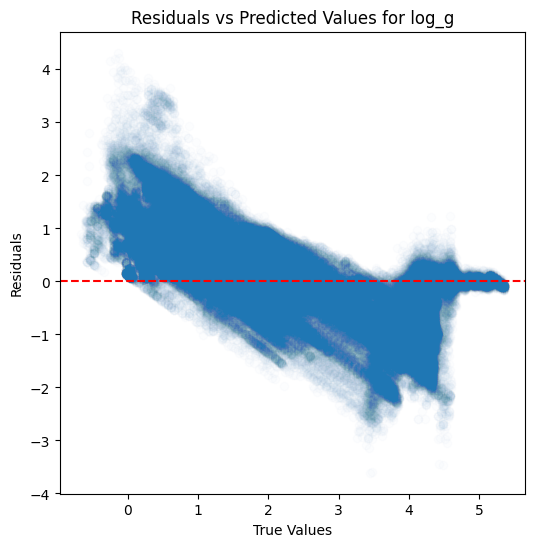

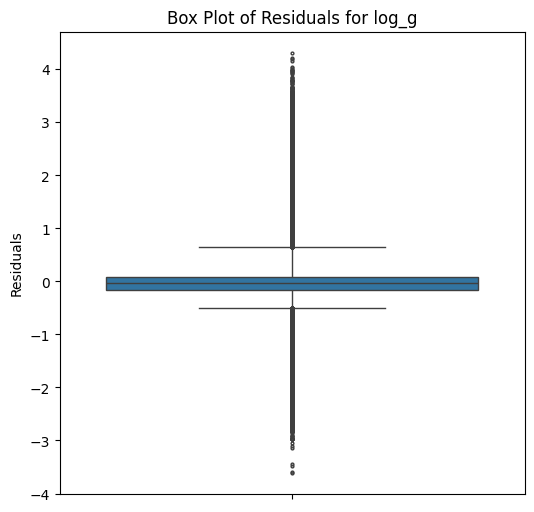

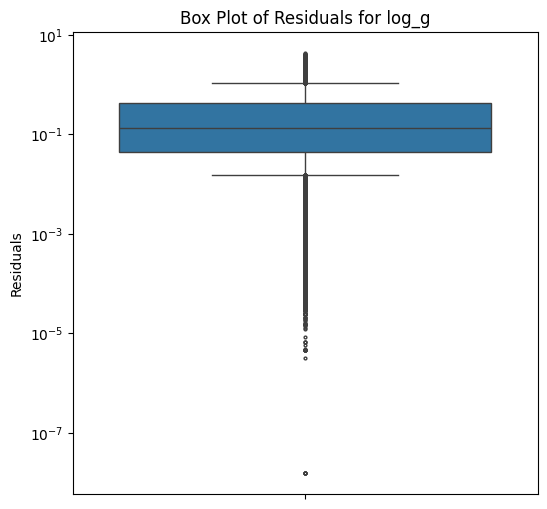

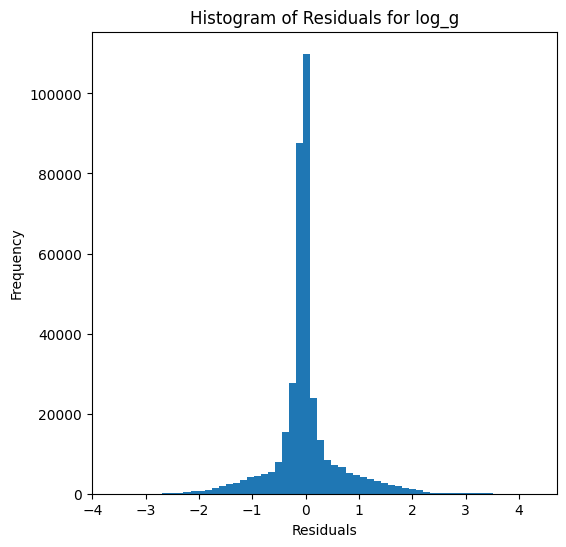

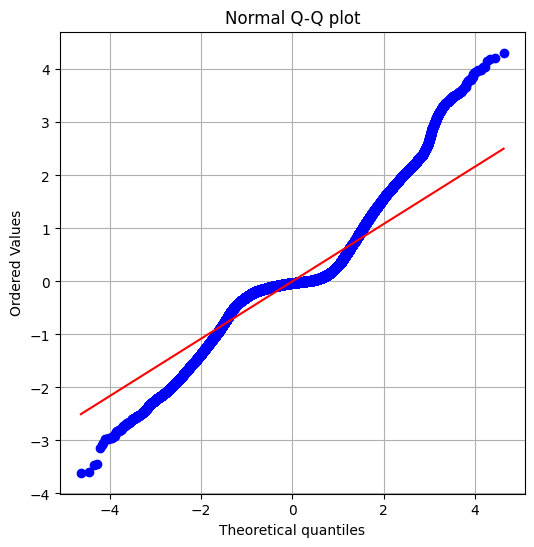


radius results:
RVE :  0.644971987003403
RMSE :  48.818406537207075
MAE :  20.50402452068042
MedAE :  5.41756591796875
CORR :  0.803173818103691
MAX_ER :  737.6564282226562
Percentiles : 
  75th percentile :  12.894091033935547
  90th percentile :  60.501872329711915
  95th percentile :  107.39506530761713
  99th percentile :  225.51151293945307



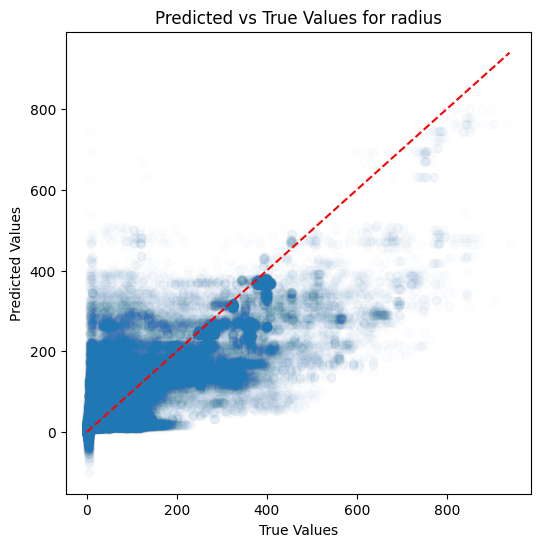

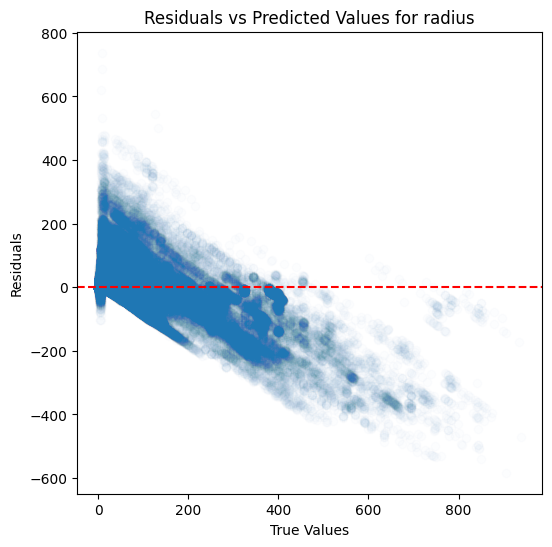

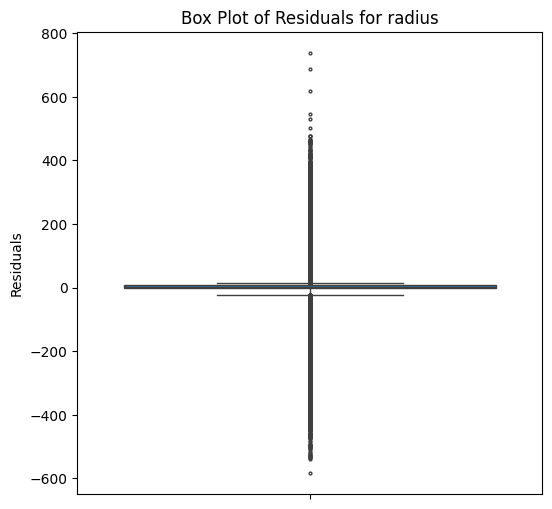

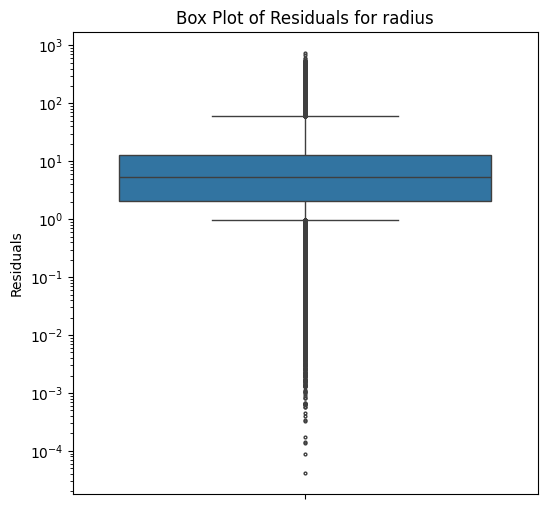

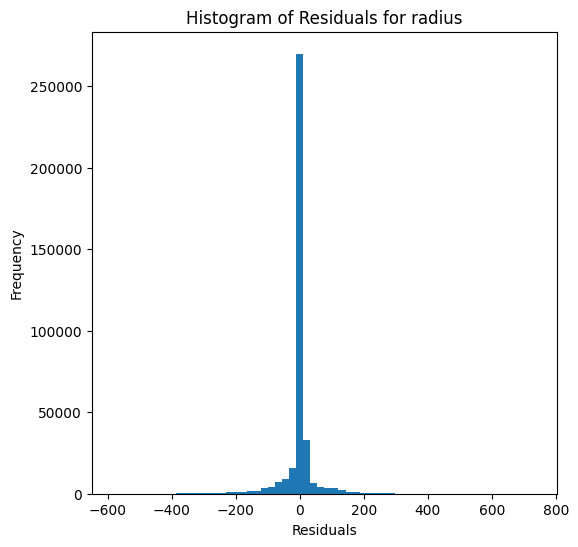

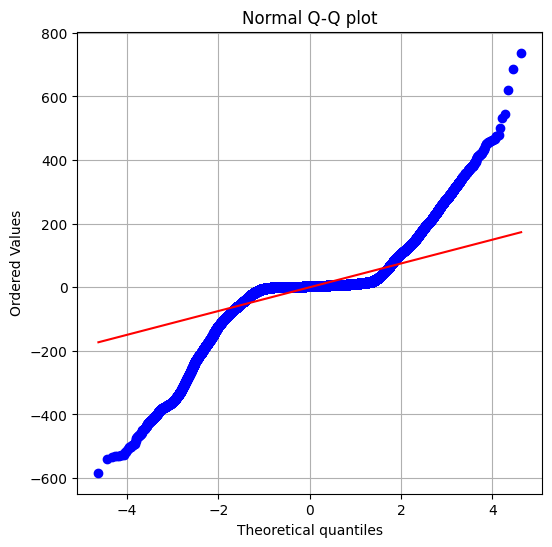

In [20]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, path_to_predictions, tag, random_state=12, override=True, use_preds=False, n_jobs=5) #, override=False, use_preds=True)

### Multi-layer perceptron

In [21]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


Base train data :
split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


574.5534880306254
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


579.7368778921492
3 

...

577.6509458812601
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


578.3577678429845
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


571.7852980567689

T_eff results:
RVE :  0.29349802783828827
RMSE :  0.13287404120395369
MAE :  0.08464315613520282
MedAE :  0.04969335149376741
CORR :  0.5917363351110152
MAX_ER :  1.0138357984643909
Percentiles : 
  75th percentile :  0.10508091653154139
  90th percentile :  0.20347048390004296
  95th percentile :  0.29377295152365146
  99th percentile :  0.5177890556241852



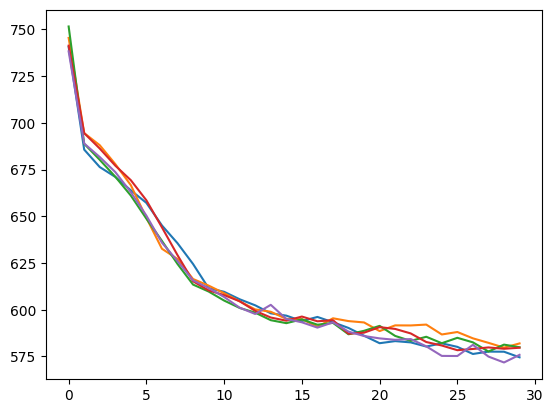

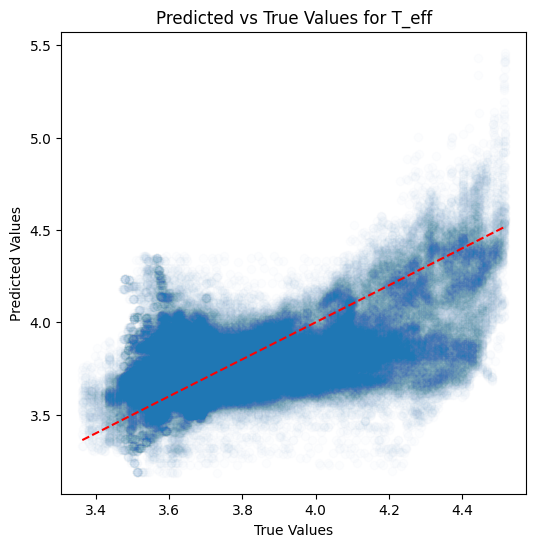

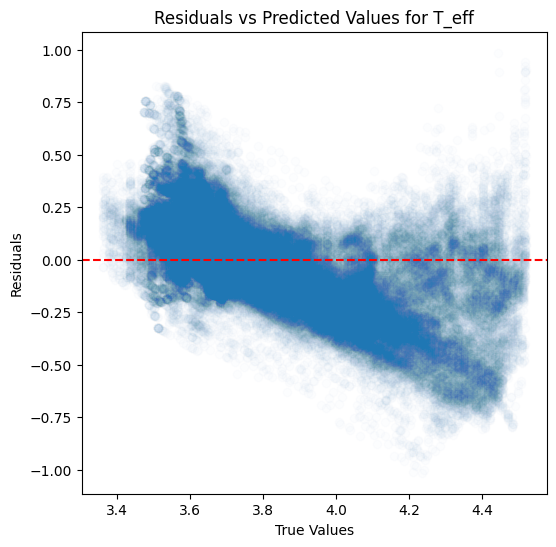

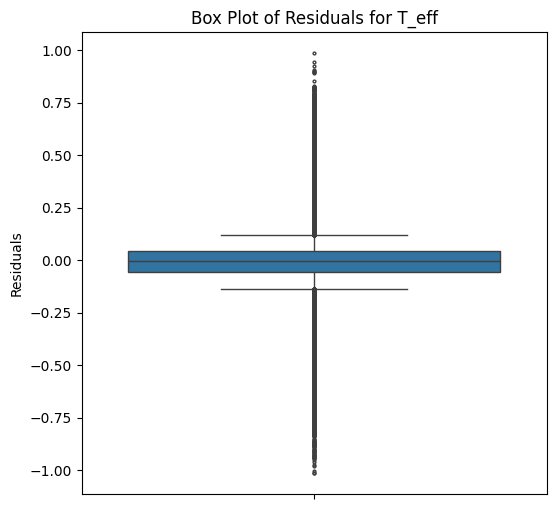

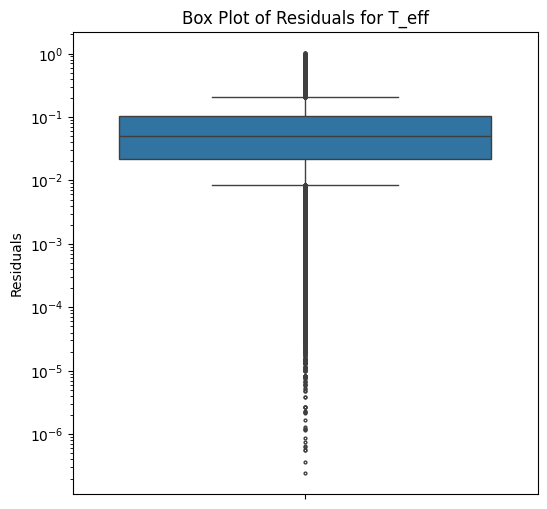

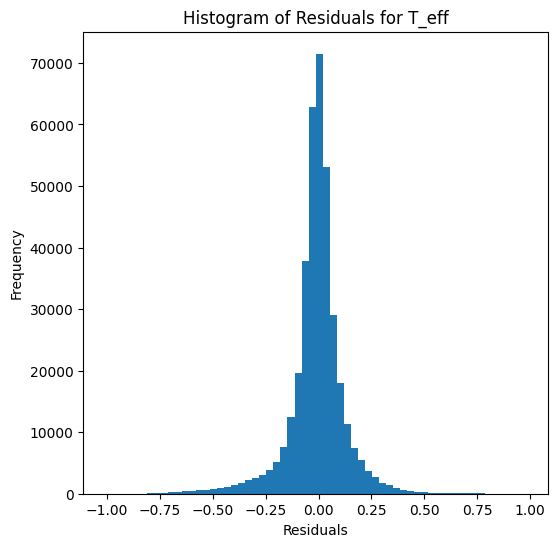

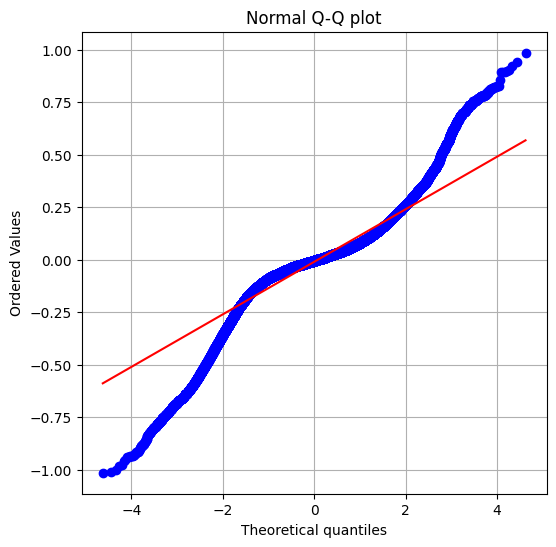


log_g results:
RVE :  0.3975239972710114
RMSE :  0.8143585954280972
MAE :  0.5097549366826154
MedAE :  0.1972961363616057
CORR :  0.633022313502023
MAX_ER :  3.8805126939285306
Percentiles : 
  75th percentile :  0.7358718319189745
  90th percentile :  1.647312153320834
  95th percentile :  1.8907502346789857
  99th percentile :  2.3993046892454175



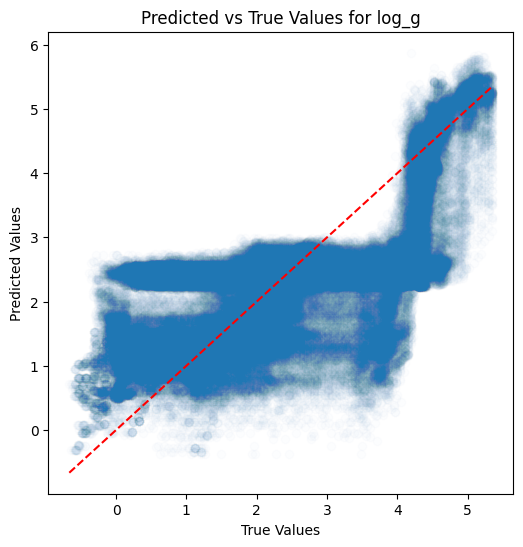

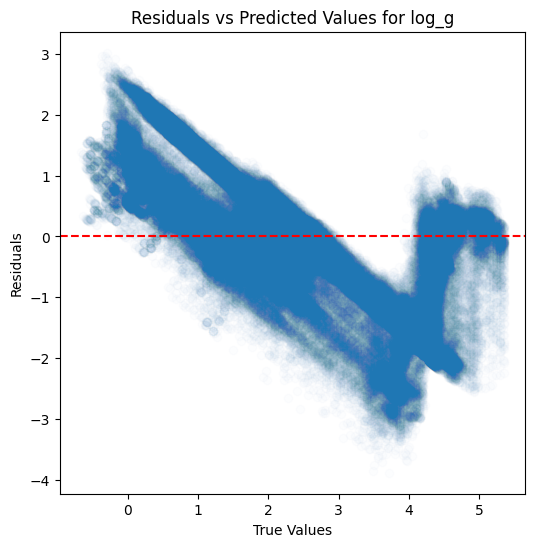

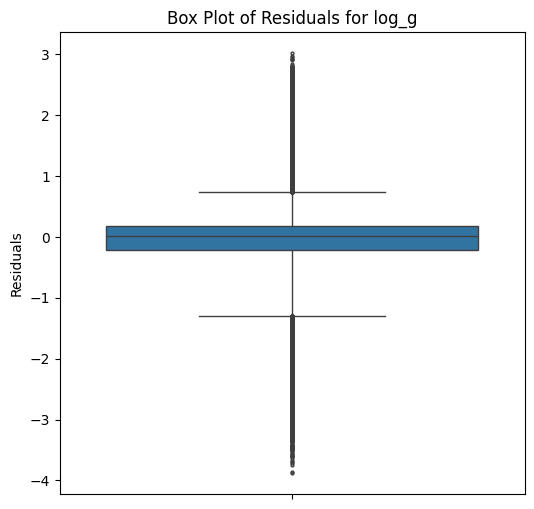

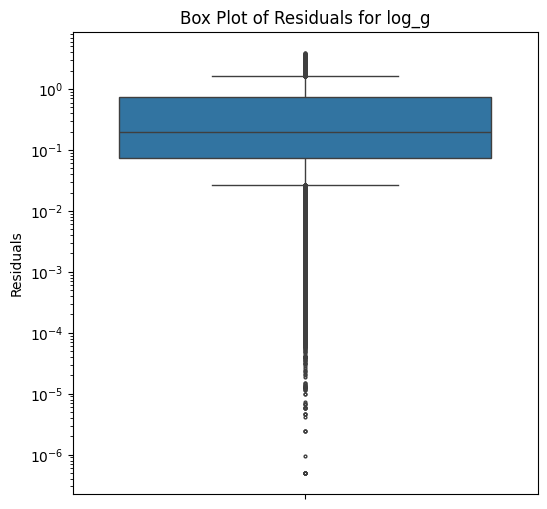

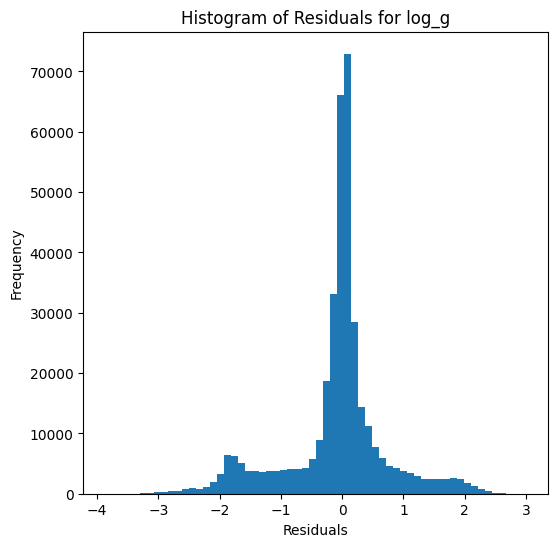

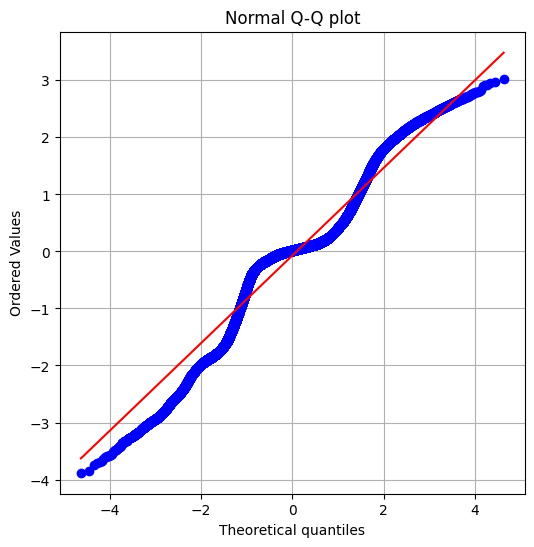


radius results:
RVE :  0.47059112876787645
RMSE :  59.655130147057825
MAE :  26.428119626090854
MedAE :  5.572267517036119
CORR :  0.6889291013402076
MAX_ER :  647.5801106189111
Percentiles : 
  75th percentile :  14.652256977608419
  90th percentile :  83.75058764609427
  95th percentile :  146.81591075253414
  99th percentile :  255.0542022134175



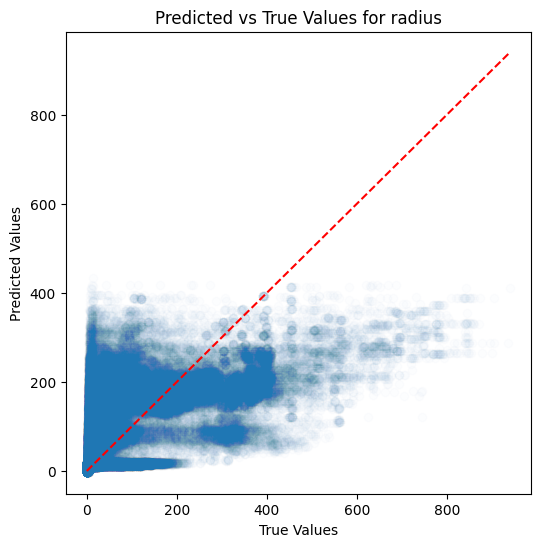

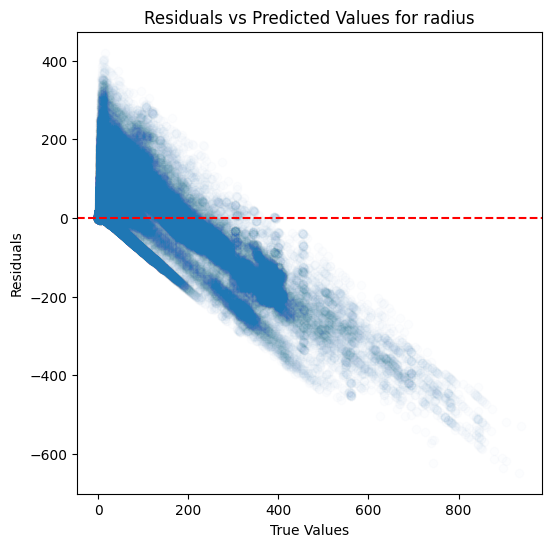

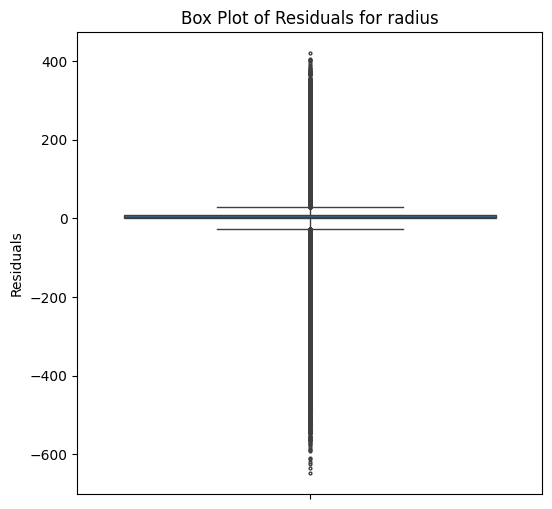

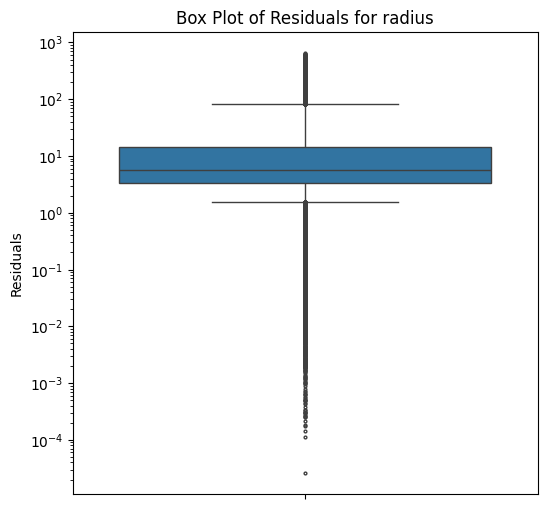

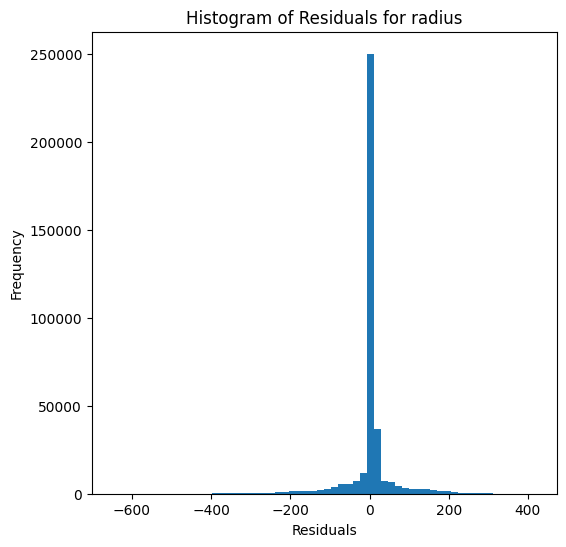

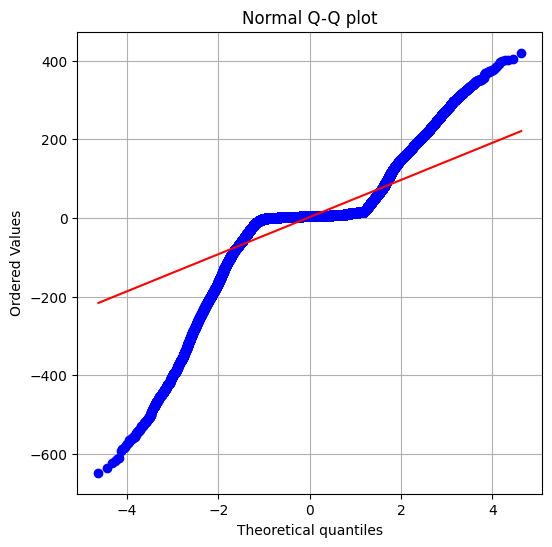

In [22]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, path_to_predictions, tag, n_splits=5, random_state=12, override=True, use_preds=False, hidden_layer_sizes = (100, 100, 100, 100), max_iter=30, batch_size=400) #, override=False, use_preds=True)